# Algorithm 16 deep dive — `examples/16_argpartition_rowsparse.py`

This is the current best surface (**submission 315718**, graded good on the leaderboard).
The notebook has three jobs:

1. **Define every hyperparameter**, how it was selected, and where refinement headroom might remain.
2. **Show how the matrix multiplication actually works** — pre-activation vs post-activation,
   the active-set restriction, the packed row-sparse path, the block split, and the Strassen contraction.
3. **Produce visuals from a real MLP** (width 256, depth 32, `build_mlp` seed 0) that surface
   patterns pointing at gaps.

Scoring context (see `docs/concepts/scoring-model.md`): the challenge scores
`adjusted_final_layer_score = final_layer_mse x max(0.1, effective_compute / flop_budget)`.
Only the **final-layer** row is graded, so intermediate rows are cheap analytical fillers, and every
FLOP saved on the sampled path lowers the multiplier roughly linearly (current multiplier ~0.33-0.38,
well above the 0.1 floor — compute savings still pay).

> Run `uv sync --extra notebook` first. Analysis cells use **plain NumPy replicas** of the estimator's
> logic (untracked, fast); the estimator itself is only executed once, under a real
> `flops.BudgetContext`. Never use untracked NumPy inside `predict()` — this is analysis-only.

**One structural fact to keep in mind throughout:** every expensive operation in this estimator is
the same rectangular matmul — `(samples x prev-active-neurons) @ (prev x curr active neurons)`.
The **sample dimension is enormous** (30,720-61,440 Sobol rows) and can be sliced or halved
indefinitely at no cost; the **neuron dimensions are scarce** (<=256 raw, ~150-230 after
dead-pruning, 64-150 after the block split). Every technique below spends the abundant dimension
to economize on the scarce ones — and every ceiling we hit (packing gates, Strassen depth, bucket
edges) is the scarce dimensions running out.


In [1]:
import sys
from pathlib import Path

import numpy as np

REPO = Path(".").resolve()
sys.path.insert(0, str(REPO))
sys.path.insert(0, str(REPO / "examples"))

import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
from importlib import import_module

algo16 = import_module("16_argpartition_rowsparse")
from local_engine import build_mlp

# ---- palette: validated reference palette (dataviz method), light mode ----
INK, INK2, MUTED = "#0b0b0b", "#52514e", "#898781"
GRID, AXISC, SURFACE = "#e1e0d9", "#c3c2b7", "#fcfcfb"
C_KINK, C_ON, C_DEAD = "#2a78d6", "#1baf7a", "#eda100"   # categorical slots 1-3, fixed order
C_GREEN, C_VIOLET, C_RED = "#008300", "#4a3aa7", "#e34948"  # slots 4-6
SEQ = LinearSegmentedColormap.from_list(
    "seqblue", ["#fcfcfb", "#cde2fb", "#9ec5f4", "#6da7ec", "#3987e5", "#256abf", "#184f95", "#0d366b"])

plt.rcParams.update({
    "figure.facecolor": SURFACE, "axes.facecolor": SURFACE, "savefig.facecolor": SURFACE,
    "axes.edgecolor": AXISC, "axes.labelcolor": INK2, "axes.titlecolor": INK,
    "xtick.color": MUTED, "ytick.color": MUTED, "text.color": INK,
    "axes.grid": True, "grid.color": GRID, "grid.linewidth": 0.8,
    "axes.spines.top": False, "axes.spines.right": False,
    "font.size": 10, "axes.titlesize": 11, "figure.dpi": 110,
})

WIDTH, DEPTH, SEED = 256, 32, 0
mlp = build_mlp(width=WIDTH, depth=DEPTH, seed=SEED)
Ws = [np.asarray(w).astype(np.float32) for w in mlp.weights]

print("hyperparameters as loaded from the module (source of truth):")
for name in ["_BASE_SAMPLES", "_ANCHOR_SAMPLES", "_MAX_SAMPLES", "_VAR_REF",
             "_DEAD_THRESH", "_ON_THRESH", "_PILOT_FRACTION", "_PILOT_RECHECK_FRACTION",
             "_PILOT_RECHECK_MARGIN", "_PACKED_ROWSPARSE_CHUNK_ROWS", "_PACKED_ROWSPARSE_BUCKET",
             "_PACKED_ROWSPARSE_ROW_BUCKETS", "_PACKED_ROWSPARSE_MAX_K_NUM", "_PACKED_ROWSPARSE_MAX_K_DEN",
             "_BLOCK_SPLIT_FIRE_THRESH", "_BLOCK_SPLIT_MIN_DENSE_COLS", "_BLOCK_SPLIT_MIN_SPARSE_COLS",
             "_DENSE_STRASSEN_MIN_ROWS", "_DENSE_STRASSEN_MIN_IN", "_DENSE_STRASSEN_MIN_OUT"]:
    print(f"  {name} = {getattr(algo16, name)}")


hyperparameters as loaded from the module (source of truth):
  _BASE_SAMPLES = 30720
  _ANCHOR_SAMPLES = 49152
  _MAX_SAMPLES = 61440
  _VAR_REF = 0.02143
  _DEAD_THRESH = -3.0
  _ON_THRESH = 3.0
  _PILOT_FRACTION = 0.05
  _PILOT_RECHECK_FRACTION = 0.2
  _PILOT_RECHECK_MARGIN = 0.35
  _PACKED_ROWSPARSE_CHUNK_ROWS = 16384
  _PACKED_ROWSPARSE_BUCKET = 16
  _PACKED_ROWSPARSE_ROW_BUCKETS = (0, 8, 16, 32, 48, 64, 80, 96, 128, 192)
  _PACKED_ROWSPARSE_MAX_K_NUM = 3
  _PACKED_ROWSPARSE_MAX_K_DEN = 4
  _BLOCK_SPLIT_FIRE_THRESH = 0.75
  _BLOCK_SPLIT_MIN_DENSE_COLS = 32
  _BLOCK_SPLIT_MIN_SPARSE_COLS = 16
  _DENSE_STRASSEN_MIN_ROWS = 4096
  _DENSE_STRASSEN_MIN_IN = 64
  _DENSE_STRASSEN_MIN_OUT = 64


## 1. Pipeline overview

`predict()` runs six stages:

1. **Analytical moment propagation** (`_initial_structure`) — diagonal Gaussian moments
   `(mu, sigma^2)` pushed through every layer with the exact ReLU-of-Gaussian formulas. Costs
   `O(width^2)` per layer; produces per-neuron `alpha = mu_pre / sigma_pre`.
2. **Neuron classification** — per layer, each neuron is **dead** (`alpha < -3`, ReLU output
   treated analytically), **always-on** (`alpha > +3`, ReLU dropped — the neuron is affine), or
   **kink** (genuinely nonlinear, must be sampled).
3. **Staged pilot probes** (base block only, `refine=True`) — cheap sampled `alpha` estimates
   (5% of rows, then 20% for neurons within +-0.35 of the threshold) promote/demote borderline
   neurons. This is the safety net for classification errors.
4. **Antithetic Sobol sampling** — a fixed 30,720-sample prefix (15,360 Sobol points and their
   negations) is pushed through the **active sub-network only** (dead columns dropped).
5. **Cheap matmul machinery** — the subject of sections 4-6: block split by fire rate, packed
   row-sparse evaluation, guarded one-level Strassen.
6. **Hardness-aware continuation** — analytical final-layer variance chooses
   `N = clip(49152*sqrt(V/V_REF), 30720, 61440)`; harder MLPs get the next Sobol prefix through
   the already-refined structure (`refine=False`).

The layer-30/31 fold (kept from Algorithm 15) treats always-on neurons of layer 30 as a linear map
folded into layer 31, so their samples never materialize.


## 2. Hyperparameters: values, selection evidence, refinement headroom

### 2a. Sampling & allocation

| name | value | role | how selected | refinement potential |
|---|---|---|---|---|
| `_BASE_SAMPLES` | 30720 | always-run antithetic prefix (15,360 Sobol pairs) | largest "easy" size whose multiplier stays cheap; doubles as the allocation floor | tied to artifact size; see MAX |
| `_ANCHOR_SAMPLES` | 49152 | budget at reference hardness `V = V_REF` | anchor of the sqrt-rule fit on public-mini profiling (`bench_logs/pathc_allocation_signal_2026-07-07.md`) | allocation family heavily probed and **tapped**: learned prior R2=0.004, analytic on-moment correction -0.02%, max-squared shape regressed (2026-07-10) |
| `_MAX_SAMPLES` | 61440 | hard cap | artifact bound: `sobol_points.npz` ships 30,720 half-samples x2 antithetic | only untested direction: **bigger Sobol artifact** (e.g. 80k cap) + a *selective* hard-MLP gate; naive max-squared already rejected |
| `_EASY_SAMPLES` | 30720 | allocation floor | = base block (no partial blocks) | low |
| `_VAR_REF` | 0.02143 | hardness normalizer | dataset-median analytical final-layer variance from public-mini | recalibrate only if dataset/phase changes |

### 2b. Classification thresholds

| name | value | role | how selected | refinement potential |
|---|---|---|---|---|
| `_DEAD_THRESH` | -3.0 | `alpha` below -> dead | `Phi(-3)=1.35e-3` -> ~0.35 expected misclassified neurons per 256-wide layer *before* probes | mostly tapped: pruned-alpha margin sweeps (`bench_logs/pruned_alpha_m*_n5_subprocess.jsonlog`) chose the probe margins around it |
| `_ON_THRESH` | +3.0 | `alpha` above -> always-on | symmetric argument; always-on error is second-order (fold is exact for truly-on neurons) | see margin-mass chart (section 3) for exposure |

### 2c. Pilot probes / refinement

| name | value | role | how selected |
|---|---|---|---|
| `_PILOT_FRACTION` | 0.05 | primary probe rows (5% of N) | cheapest probe that keeps sampled-alpha noise ~ `sqrt(1/1536)` ~ 0.026 |
| `_PILOT_RECHECK_FRACTION` | 0.20 | recheck rows for uncertain neurons | 4x primary; only spent on the +-margin band |
| `_PILOT_RECHECK_MARGIN` | 0.35 | half-width of "uncertain" band | ~13 sigma of primary-probe noise; wide enough to catch drift |
| `_PILOT_ON_THRESH` / `_PILOT_DEAD_THRESH` | +3.0 / -2.5 | sampled promote/demote thresholds | dead-side is looser (-2.5): promoting a live neuron back to sampled is cheap, missing one biases the mean; swept m in {2.0, 2.5, 3.0}, -2.5 kept |
| `_ON_PROBE_MAX` / `_DEAD_PROBE_MIN` | +4.0 / -4.0 | trust bands: neurons beyond these are never re-probed | probe cost control; `Phi(-4)=3e-5` residual risk |
| `_REFINE_DEAD_*`, `_DEMOTE_ACTIVE_DEAD_*` | layers 1..29 | probe window | layer 0 is exact analytically; 30/31 have their own fold-path probes |
| `_ACTIVE_DEAD_PROBE_MAX` / `_ACTIVE_DEAD_THRESH` | -2.5 / -3.0 | demotion of near-dead kinks | mirror of the promote path |

### 2d. Packed row-sparse path

| name | value | role | how selected | refinement potential |
|---|---|---|---|---|
| `_PACKED_ROWSPARSE_START/STOP_LAYER` | 1..29 | packing window | layer 0 has the antithetic half-trick; 30/31 use the fold | — |
| `_PACKED_ROWSPARSE_CHUNK_ROWS` | 16384 | rows per packing chunk | memory: the gathered-weights tensor is `16384 x k x 256 x 4B` ~ 3.2 GiB at k=192 — just under the grader's **4 GiB per-array cap** | do **not** raise; lowering costs more chunk-loop residual |
| `_PACKED_ROWSPARSE_BUCKET` | 16 | k rounded up to multiple of 16 | argpartition/gather amortization granularity | interacts with bucket edges below |
| `_PACKED_ROWSPARSE_ROW_BUCKETS` | (0,8,16,32,48,64,80,96,128,192) | nnz-per-row group edges | iterated across submissions ("finer row-bucket", "plus-80" — the 80 edge was added where occupancy mass sat between 64 and 96) | **live lever**: section 5's occupancy/fill charts show where edges misfit mass |
| `_PACKED_ROWSPARSE_MAX_K_NUM/_DEN` | 3/4 | rows with nnz > 0.75p fall back to dense | gate sweep 2026-07-09: 0.75 is the wall-time-safe frontier — 0.5/0.4 erase the saving, extending naive packing doubled wall time (submissions 315417/315420 failed remotely) | tapped as a *family*; only the bucket geometry inside it is live |
| `_PACKED_ROWSPARSE_EXTRA_BLOCKS` | True | pack the continuation block too | originally failed (315417) as naive packing; re-enabled once block-split + mask reuse + put-unsort cut the packed path's wall cost — validated by 315718 | — |

### 2e. Block split (dense high-fire block)

| name | value | role | how selected |
|---|---|---|---|
| `_BLOCK_SPLIT_FIRE_THRESH` | 0.75 | columns firing on >=75% of rows go to the dense block | those columns carry most nnz mass; removing them makes the remainder *actually* sparse |
| `_BLOCK_SPLIT_MIN_DENSE/SPARSE_COLS` | 32 / 16 | skip the split when either block is too thin | overhead guard (two matmuls + adds must beat one) |

### 2f. Strassen gates

| name | value | role | how selected | refinement potential |
|---|---|---|---|---|
| `_DENSE_STRASSEN` | True | one-level Strassen on big dense matmuls | measured 88.1% of dense FLOPs, exact to ~1e-6, wall-safe (`bench_logs/strassen_walltime_probe_2026-07-09.md`) | **live lever**: section 8 — two-level, Winograd adds, gate relaxation |
| `_DENSE_STRASSEN_MIN_ROWS/IN/OUT` | 4096 / 64 / 64 | keep probes and small blocks on plain `@` | probe paths are wall-sensitive, small blocks don't amortize the 18 block-adds | the 64-gates also *disable* Strassen on thin post-split blocks — quantified in section 8 |

Also: `_MATERIALIZE_INTERMEDIATE_ROWS=False` — only the final row is graded, so intermediate rows
are the analytical means (free accuracy trade that is pure multiplier win).


### 2g. Summary — which hyperparameters are worth tuning

Ranked by expected value, given the sweep history above and the analysis in sections 5 and 8:

| priority | hyperparameter(s) | why it's live | how to tune |
|---|---|---|---|
| **1** | `_DENSE_STRASSEN_MIN_IN/OUT/ROWS` + recursion depth (new inner gate) | the §8 lever: 2-level Winograd models to ~78% of dense vs 88% shipped; ~4% of dense-path FLOPs currently bypass Strassen on thin blocks | implement 2-level + per-shape depth dispatch; fixed-seed `--profile` sweep of inner min-block in {16, 24, 32, 48} |
| **2** | `_BLOCK_SPLIT_FIRE_THRESH` (0.75) | set before Strassen existed; the split *spends* neuron width that recursion now wants (§8c) — and Strassen beat packing outright in the 07-09 A/B | co-sweep with Strassen depth: {0.5, 0.6, 0.75} x {1, 2} levels, score + wall |
| **3** | `_PACKED_ROWSPARSE_ROW_BUCKETS` | the one live packing lever; §5 occupancy/fill charts show where mass hugs an edge (the +80 precedent paid) | add/move edges where fill ratio is low and rows are many; merge near-empty buckets to cut einsum launches (residual) |
| **4** | `_MAX_SAMPLES` (61440) | the only untested allocation direction — but requires a bigger `sobol_points.npz` artifact and a *selective* hard-MLP gate | only alongside an artifact rebuild; naive shapes already rejected (max-squared, 07-10) |

**Explicitly not worth re-tuning** (swept to their frontier, or externally capped):
`_PACKED_ROWSPARSE_MAX_K_NUM/_DEN` (0.75 is the wall-time-safe frontier — gate sweep 07-09),
`_DEAD_THRESH`/`_ON_THRESH` and the probe margins (pruned-alpha sweeps),
`_VAR_REF` and the sqrt allocation shape (tapped: learned prior R2 = 0.004),
`_PACKED_ROWSPARSE_CHUNK_ROWS` (pinned just under the grader's 4 GiB per-array cap).

Note the top two interact: they should land in **one** benchmark sweep, not sequential ones —
widening the dense block only pays if the recursion that consumes it is already in place.


## 3. The analytical pass: `alpha` and neuron classification

Replicated below in plain NumPy (identical math to `_initial_structure`):
pre-activation moments `mu_pre = W^T mu_post`, `var_pre = (W*W)^T var_post`, then the exact
ReLU-of-Gaussian update

```
mu_post  = mu_pre*Phi(alpha) + sigma_pre*phi(alpha)          alpha = mu_pre / sigma_pre
var_post = (var_pre + mu_pre^2)*Phi(alpha) + mu_pre*sigma_pre*phi(alpha) - mu_post^2
```

This is exact at layer 0 (true Gaussian input) and a diagonal approximation afterwards.


In [2]:
from math import erf

_verf = np.vectorize(erf)

def Phi(x):
    return 0.5 * (1.0 + _verf(x / np.sqrt(2.0)))

def phi(x):
    return np.exp(-0.5 * x * x) / np.sqrt(2.0 * np.pi)

def analytic_structure(Ws):
    width = Ws[0].shape[0]
    mu_post = np.zeros(width)
    var_post = np.zeros(width)
    alphas, post_means = [], []
    for li, w in enumerate(Ws):
        if li == 0:
            mu_pre = np.zeros(width)
            var_pre = (w * w).sum(axis=0)
        else:
            mu_pre = w.T @ mu_post
            var_pre = (w * w * var_post[:, None]).sum(axis=0)
        var_pre = np.maximum(var_pre, 1e-12)
        sigma = np.sqrt(var_pre)
        a = mu_pre / sigma
        alphas.append(a)
        P, p = Phi(a), phi(a)
        mu_post = mu_pre * P + sigma * p
        var_post = np.maximum((var_pre + mu_pre ** 2) * P + mu_pre * sigma * p - mu_post ** 2, 1e-12)
        post_means.append(mu_post.copy())
    return np.stack(alphas), np.stack(post_means), var_post

alphas, post_means, var_post_final = analytic_structure(Ws)
final_var_mean = float(var_post_final.mean())

dead = alphas < algo16._DEAD_THRESH
on = alphas > algo16._ON_THRESH
kink = ~dead & ~on
active_idx = [np.nonzero(~dead[l])[0] for l in range(DEPTH)]

target_N = algo16._choose_samples(final_var_mean)
print(f"analytical final-layer variance mean: {final_var_mean:.5f}   (V_REF = {algo16._VAR_REF})")
print(f"allocation rule chooses N = {target_N} samples for this MLP")
print(f"mean per-layer counts: dead {dead.sum(1).mean():.1f}, kink {kink.sum(1).mean():.1f}, "
      f"on {on.sum(1).mean():.1f}  (of {WIDTH})")


analytical final-layer variance mean: 0.04437   (V_REF = 0.02143)
allocation rule chooses N = 61440 samples for this MLP
mean per-layer counts: dead 43.3, kink 167.1, on 45.6  (of 256)


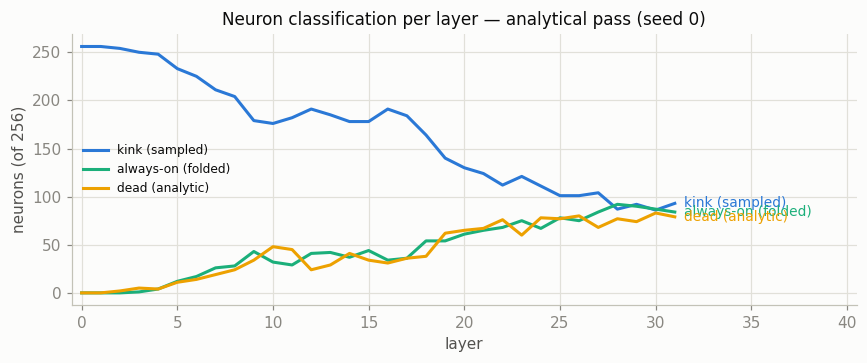

In [3]:
fig, ax = plt.subplots(figsize=(8, 3.4))
layers = np.arange(DEPTH)
for arr, name, c in [(kink, "kink (sampled)", C_KINK),
                     (on, "always-on (folded)", C_ON),
                     (dead, "dead (analytic)", C_DEAD)]:
    counts = arr.sum(axis=1)
    ax.plot(layers, counts, color=c, lw=2, label=name)
    ax.annotate(name, (layers[-1], counts[-1]), xytext=(6, 0), textcoords="offset points",
                color=c, fontsize=9, va="center")
ax.set_xlim(-0.5, DEPTH + 8.5)
ax.set_xlabel("layer")
ax.set_ylabel(f"neurons (of {WIDTH})")
ax.set_title("Neuron classification per layer — analytical pass (seed 0)")
ax.legend(frameon=False, loc="center left", fontsize=8)
plt.tight_layout()
plt.show()


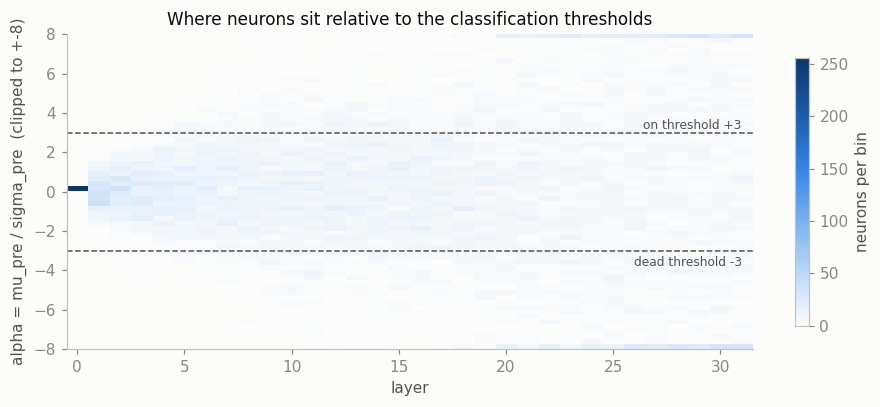

neuron-layers inside the +-0.35 probe-recheck band: 702 of 8192 (8.57%) — this is the misclassification exposure the staged probes exist to police


In [4]:
bins = np.arange(-8, 8.25, 0.25)
H = np.stack([np.histogram(np.clip(alphas[l], -7.9, 7.9), bins=bins)[0] for l in range(DEPTH)])

fig, ax = plt.subplots(figsize=(8.6, 3.8))
im = ax.imshow(H.T, origin="lower", aspect="auto", cmap=SEQ,
               extent=[-0.5, DEPTH - 0.5, bins[0], bins[-1]])
for t, lbl, dy in [(algo16._ON_THRESH, "on threshold +3", 0.2),
                   (algo16._DEAD_THRESH, "dead threshold -3", -0.75)]:
    ax.axhline(t, color=INK2, lw=1, ls="--")
    ax.text(DEPTH - 1, t + dy, lbl, color=INK2, fontsize=8, ha="right")
ax.set_xlabel("layer")
ax.set_ylabel("alpha = mu_pre / sigma_pre  (clipped to +-8)")
ax.set_title("Where neurons sit relative to the classification thresholds")
ax.grid(False)
fig.colorbar(im, ax=ax, label="neurons per bin", shrink=0.85)
plt.tight_layout()
plt.show()

in_margin = (np.abs(alphas - algo16._ON_THRESH) < algo16._PILOT_RECHECK_MARGIN) | \
            (np.abs(alphas - algo16._DEAD_THRESH) < algo16._PILOT_RECHECK_MARGIN)
print(f"neuron-layers inside the +-{algo16._PILOT_RECHECK_MARGIN} probe-recheck band: "
      f"{in_margin.sum()} of {DEPTH * WIDTH} ({in_margin.mean():.2%}) — this is the "
      f"misclassification exposure the staged probes exist to police")


## 4. How the matrix multiplication works: pre-activation vs post-activation

For layer `l` with active sets `A_{l-1}` (previous layer, size `p`) and `A_l` (this layer, size `q`),
the sampled state is the **post-activation** matrix `X_post` with shape `(N, p)`:

```
PRE  = X_post @ W[A_{l-1}, A_l]        # (N, p) @ (p, q) -> (N, q)   <- all the FLOPs live here
X_post' = max(PRE, 0)                  # ReLU, elementwise            <- creates the sparsity
row_l  = mean(X_post', axis=0)         # the returned estimate for layer l (final layer only)
```

**Dimension roles in dataset terms.** Rows of `X_post` are Monte-Carlo **samples** — plentiful
(30,720 base, up to 61,440) and interchangeable; columns are **neurons** — scarce (`p, q <= 256`,
shrinking as classification prunes). The three cost levers each exploit one side of this asymmetry:
*packing* exploits per-sample (row-wise) sparsity, the *block split* exploits per-neuron
(column-wise) density, and *Strassen recursion* is rationed entirely by the neuron dimensions
(section 8). Whenever a shape `(N, p, q)` appears below: `N` = samples, `p` = previous layer's
active neurons, `q` = current layer's active neurons.

Three structural facts make this cheaper than a dense forward pass:

1. **Active-set restriction** — dead columns never enter `W[A_{l-1}, A_l]`; classification shrinks
   `p, q` from 256 to whatever survives (section 3).
2. **Antithetic layer 0** — inputs come in `(x, -x)` pairs, and `|pre|` is shared:
   `relu(x@W) = max(pre, 0)`, `relu(-x@W) = max(-pre, 0)`. One half-size matmul serves all
   30,720 rows (`estimator.py` line ~546).
3. **ReLU sparsity** — after ReLU, each *row* of `X_post` has many zeros. A zero input contributes
   nothing to the next matmul, so those multiplies can be skipped **exactly** (packing changes the
   evaluation order, never the values — `pred-identity <= 1e-6` vs dense, and raw MSE is bit-identical).

### The packed row-sparse path (`_packed_matmul`)

Per 16,384-row chunk: count `nnz` per row -> `argsort` rows by nnz -> group rows into the
`_PACKED_ROWSPARSE_ROW_BUCKETS` edges -> per group, round the bucket limit up to a multiple of 16
to get `k`, `argpartition` each row's mask to find its top-`k` columns, gather `(values, weights)`
and contract with `einsum("nk,nko->no")` — a per-row `k`-sparse matmul costing `2*rows*k*q` instead
of `2*rows*p*q`. Rows with `nnz > (3/4)p` fall back to plain dense. `put_along_axis` restores the
original row order (the 315718 improvement). Gathers/sorts are FLOP-free in flopscope but cost
**residual wall time** — that is the tax that killed the naive variants.

### The block split (`_split_matmul_with_fire`)

Columns firing on >= 75% of rows are dense in every row — packing them is pure padding. They are
split into a dense `(N, |hot|) @ (|hot|, q)` matmul (Strassen-eligible), and only the genuinely
sparse remainder goes through packing.

### The Strassen contraction (`_strassen_even_matmul`)

Dense matmuls with `rows >= 4096` and both dims `>= 64` use one level of 2x2x2 Strassen
(7 block products instead of 8; odd edges peeled and added back). flopscope counts the real
scalar multiplies, so this is an honest ~12% FLOP cut on eligible matmuls at ~1e-6 max error.

Below, an instrumented plain-NumPy replica of the base-block forward pass records what actually
flows through each path. (Simplifications: pilot probes and the layer-30/31 fold are omitted —
classification here is the analytical one, layers 1..29 only, which is exactly the packing window.)


In [5]:
BUCKETS = list(algo16._PACKED_ROWSPARSE_ROW_BUCKETS)
BROUND = algo16._PACKED_ROWSPARSE_BUCKET
KNUM, KDEN = algo16._PACKED_ROWSPARSE_MAX_K_NUM, algo16._PACKED_ROWSPARSE_MAX_K_DEN
CHUNK = algo16._PACKED_ROWSPARSE_CHUNK_ROWS
FIRE = algo16._BLOCK_SPLIT_FIRE_THRESH
SMINR = algo16._DENSE_STRASSEN_MIN_ROWS
SMINI = algo16._DENSE_STRASSEN_MIN_IN
SMINO = algo16._DENSE_STRASSEN_MIN_OUT
# measured one-level total-FLOP ratio incl. block adds (bench_logs/strassen_walltime_probe_2026-07-09.md)
STRASSEN1_FACTOR = 0.881

def strassen_eligible(n, p, q):
    return n >= SMINR and p >= SMINI and q >= SMINO

def packed_groups(mask_sub, p_width):
    """Replicates _packed_matmul's chunk/bucket routing. Returns (kind, limit, rows, k, useful_nnz)."""
    groups = []
    n = mask_sub.shape[0]
    for start in range(0, n, CHUNK):
        m = mask_sub[start:start + CHUNK]
        snnz = np.sort(m.sum(axis=1))
        limits = [b for b in BUCKETS + [p_width] if b <= p_width]
        gs = 0
        for lim in limits:
            ge = int((snnz <= lim).sum())
            if ge <= gs:
                continue
            rows, group_nnz = ge - gs, snnz[gs:ge]
            if lim == 0:
                groups.append(("zero", 0, rows, 0, 0))
            else:
                k = min(p_width, -(-lim // BROUND) * BROUND)
                if k * KDEN > p_width * KNUM:
                    groups.append(("dense-fallback", lim, rows, p_width, int(group_nnz.sum())))
                else:
                    groups.append(("packed", lim, rows, k, int(group_nnz.sum())))
            gs = ge
            if gs == len(snnz):
                break
        if gs < len(snnz):
            groups.append(("dense-fallback", p_width, len(snnz) - gs, p_width, int(snnz[gs:].sum())))
    return groups

pts = np.load(str(REPO / "sobol_points.npz"))["points"]
half = pts[: algo16._BASE_SAMPLES // 2, :WIDTH].astype(np.float32)

# layer 0: antithetic half-trick
pre_half = half @ Ws[0][:, active_idx[0]]
x = np.concatenate([np.maximum(pre_half, 0.0), np.maximum(-pre_half, 0.0)], axis=0)
dense_shapes = [("layer0", half.shape[0], WIDTH, len(active_idx[0]))]

sampled_rows = np.zeros((30, WIDTH))  # sampled per-layer means, layers 0..29 (dead cols filled analytically)
row0 = np.zeros(WIDTH)
row0[active_idx[0]] = x.mean(axis=0)
row0[dead[0]] = post_means[0][dead[0]]
sampled_rows[0] = row0

records = []
for l in range(1, 30):
    w_act = Ws[l][np.ix_(active_idx[l - 1], active_idx[l])]
    p, q = w_act.shape
    N = x.shape[0]
    mask = x > 0
    fire = mask.mean(axis=0)
    dense_pos = np.nonzero(fire >= FIRE)[0]
    sparse_pos = np.nonzero(fire < FIRE)[0]
    do_split = (len(dense_pos) >= algo16._BLOCK_SPLIT_MIN_DENSE_COLS
                and len(sparse_pos) >= algo16._BLOCK_SPLIT_MIN_SPARSE_COLS)
    if not do_split:
        dense_pos = np.array([], dtype=int)
        sparse_pos = np.arange(p)

    groups = packed_groups(mask[:, sparse_pos], len(sparse_pos))
    nnz_sparse = mask[:, sparse_pos].sum(axis=1)

    fl_dense_split = 2.0 * N * len(dense_pos) * q
    if len(dense_pos):
        dense_shapes.append((f"L{l}-split", N, len(dense_pos), q))
        if strassen_eligible(N, len(dense_pos), q):
            fl_dense_split *= STRASSEN1_FACTOR
    fl_packed = fl_useful = fl_pad = fl_fallback = 0.0
    for kind, lim, rows, k, useful in groups:
        if kind == "packed":
            fl_packed += 2.0 * rows * k * q
            fl_useful += 2.0 * useful * q
            fl_pad += 2.0 * (rows * k - useful) * q
        elif kind == "dense-fallback":
            c = 2.0 * rows * len(sparse_pos) * q
            dense_shapes.append((f"L{l}-fallback", rows, len(sparse_pos), q))
            if strassen_eligible(rows, len(sparse_pos), q):
                c *= STRASSEN1_FACTOR
            fl_fallback += c

    records.append(dict(layer=l, N=N, p=p, q=q,
                        n_dense_cols=len(dense_pos), n_sparse_cols=len(sparse_pos),
                        fire=fire, nnz=nnz_sparse, groups=groups,
                        fl_dense_split=fl_dense_split, fl_packed=fl_packed,
                        fl_useful=fl_useful, fl_pad=fl_pad, fl_fallback=fl_fallback,
                        fl_baseline=2.0 * N * p * q))
    x = np.maximum(x @ w_act, 0.0)  # exact result — the routing above only changes evaluation cost
    rowl = np.zeros(WIDTH)
    rowl[active_idx[l]] = x.mean(axis=0)
    rowl[dead[l]] = post_means[l][dead[l]]
    sampled_rows[l] = rowl

tot = lambda key: sum(r[key] for r in records) / 1e9
print(f"layers 1-29, base block (Gflop):  plain dense baseline {tot('fl_baseline'):.1f}")
print(f"  realized: dense high-fire {tot('fl_dense_split'):.1f}  +  packed {tot('fl_packed'):.1f} "
      f"(useful {tot('fl_useful'):.1f} / padding {tot('fl_pad'):.1f})  +  dense fallback {tot('fl_fallback'):.1f}")
realized = tot('fl_dense_split') + tot('fl_packed') + tot('fl_fallback')
print(f"  saving vs dense: {1 - realized / tot('fl_baseline'):.1%}")


layers 1-29, base block (Gflop):  plain dense baseline 83.6
  realized: dense high-fire 33.5  +  packed 16.5 (useful 13.5 / padding 3.0)  +  dense fallback 0.0
  saving vs dense: 40.1%


## 5. Patterns in the sampled state

**Fire rates** decide the dense/sparse split. **nnz per row** decides the packing buckets.
Padding (the gap between a row's true nnz and its bucket's rounded `k`) is the internal waste of
the packed path — multiplies spent on gathered zeros.


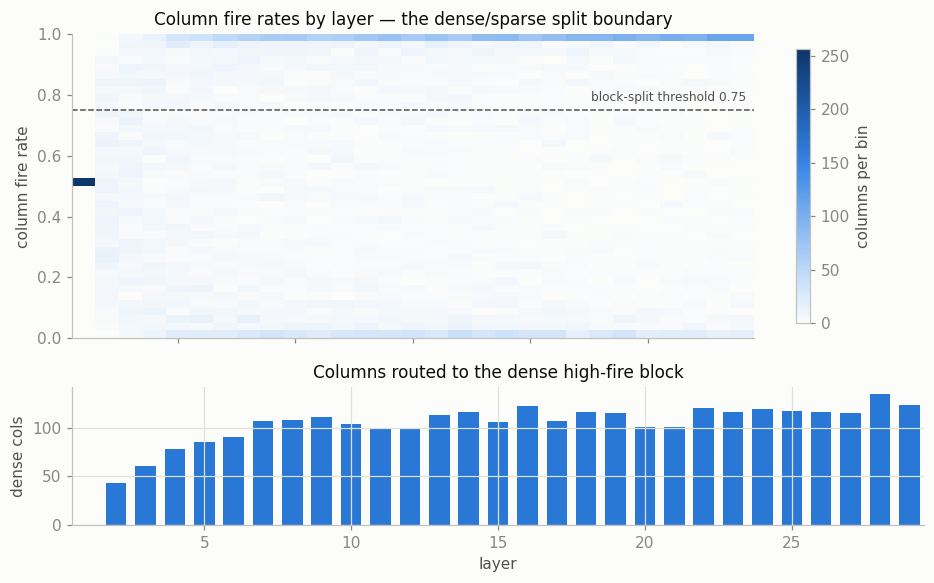

In [6]:
fig, axes = plt.subplots(2, 1, figsize=(8.6, 5.4), sharex=True, height_ratios=[2.2, 1])
ax = axes[0]
fbins = np.linspace(0, 1, 41)
Hf = np.stack([np.histogram(r["fire"], bins=fbins)[0] for r in records])
im = ax.imshow(Hf.T, origin="lower", aspect="auto", cmap=SEQ, extent=[0.5, 29.5, 0, 1])
ax.axhline(FIRE, color=INK2, lw=1, ls="--")
ax.text(29.2, FIRE + 0.03, "block-split threshold 0.75", color=INK2, fontsize=8, ha="right")
ax.set_ylabel("column fire rate")
ax.set_title("Column fire rates by layer — the dense/sparse split boundary")
ax.grid(False)
fig.colorbar(im, ax=ax, label="columns per bin", shrink=0.9)

ax2 = axes[1]
ax2.bar([r["layer"] for r in records], [r["n_dense_cols"] for r in records],
        color=C_KINK, width=0.7)
ax2.set_xlabel("layer")
ax2.set_ylabel("dense cols")
ax2.set_title("Columns routed to the dense high-fire block")
plt.tight_layout()
plt.show()


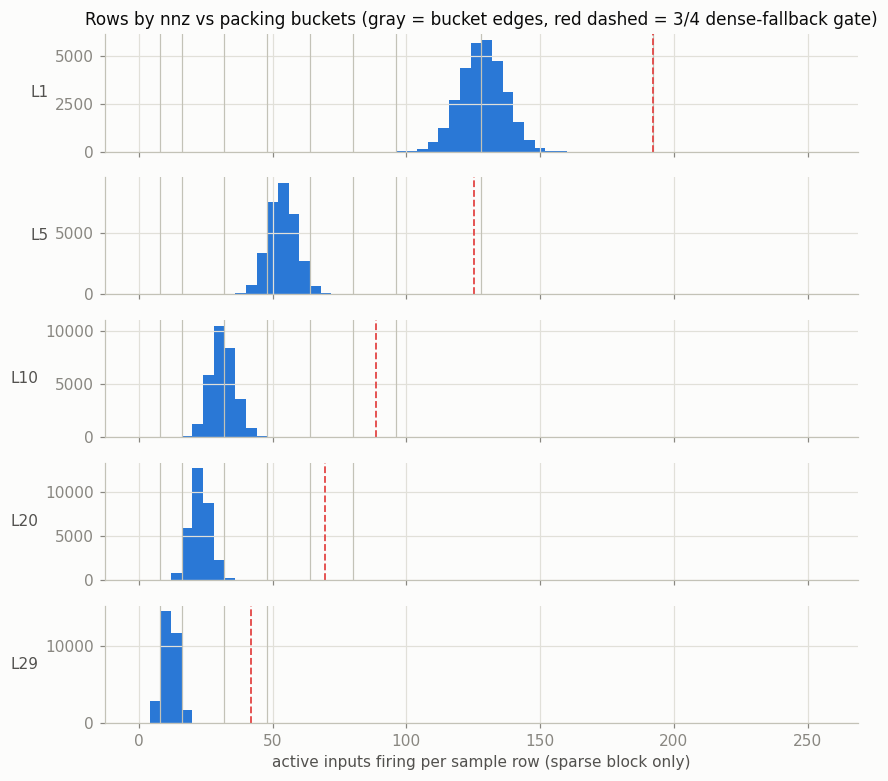

In [7]:
show_layers = [1, 5, 10, 20, 29]
fig, axes = plt.subplots(len(show_layers), 1, figsize=(8, 7.2), sharex=True)
for ax, l in zip(axes, show_layers):
    r = records[l - 1]
    ax.hist(r["nnz"], bins=np.arange(0, r["n_sparse_cols"] + 4, 4), color=C_KINK)
    for b in BUCKETS:
        if 0 < b <= r["n_sparse_cols"]:
            ax.axvline(b, color=AXISC, lw=0.8)
    ax.axvline(r["n_sparse_cols"] * KNUM / KDEN, color=C_RED, lw=1.2, ls="--")
    ax.set_ylabel(f"L{l}", rotation=0, ha="right", va="center", color=INK2)
axes[0].set_title("Rows by nnz vs packing buckets (gray = bucket edges, red dashed = 3/4 dense-fallback gate)")
axes[-1].set_xlabel("active inputs firing per sample row (sparse block only)")
plt.tight_layout()
plt.show()


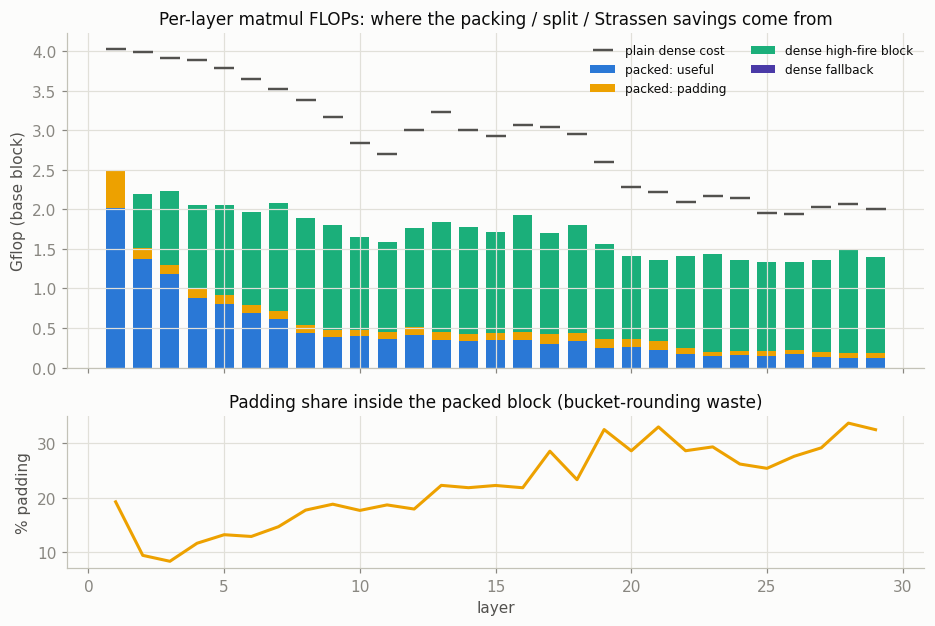

In [8]:
layersr = [r["layer"] for r in records]
segs = [("packed: useful", "fl_useful", C_KINK),
        ("packed: padding", "fl_pad", C_DEAD),
        ("dense high-fire block", "fl_dense_split", C_ON),
        ("dense fallback", "fl_fallback", C_VIOLET)]

fig, axes = plt.subplots(2, 1, figsize=(8.6, 5.8), sharex=True, height_ratios=[2.2, 1])
ax = axes[0]
bottom = np.zeros(len(records))
for name, key, c in segs:
    vals = np.array([r[key] for r in records]) / 1e9
    ax.bar(layersr, vals, bottom=bottom, color=c, width=0.7, label=name)
    bottom += vals
base = np.array([r["fl_baseline"] for r in records]) / 1e9
ax.plot(layersr, base, ls="none", marker="_", ms=13, mew=1.6, color=INK2, label="plain dense cost")
ax.set_ylabel("Gflop (base block)")
ax.set_title("Per-layer matmul FLOPs: where the packing / split / Strassen savings come from")
ax.legend(frameon=False, fontsize=8, ncol=2)

ax2 = axes[1]
waste = np.array([100 * r["fl_pad"] / max(r["fl_packed"], 1e-9) for r in records])
ax2.plot(layersr, waste, color=C_DEAD, lw=2)
ax2.set_xlabel("layer")
ax2.set_ylabel("% padding")
ax2.set_title("Padding share inside the packed block (bucket-rounding waste)")
plt.tight_layout()
plt.show()


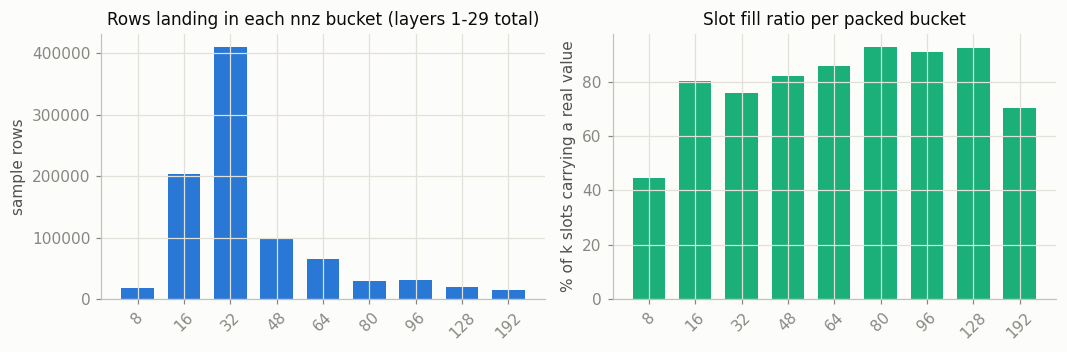

Gap check: buckets with low fill ratio + many rows are where a new edge (like the +80 one)
would pay; buckets with few rows are candidates to merge (fewer einsum launches -> less residual).


In [9]:
from collections import defaultdict

rows_per = defaultdict(int)
useful_per = defaultdict(int)
slots_per = defaultdict(int)
for r in records:
    for kind, lim, rows, k, useful in r["groups"]:
        key = "dense-fb" if kind == "dense-fallback" else str(lim)
        rows_per[key] += rows
        if kind == "packed":
            slots_per[key] += rows * k
            useful_per[key] += useful

order = [str(b) for b in BUCKETS] + ["dense-fb"]
order = [k for k in order if rows_per.get(k)]
packed_keys = [k for k in order if slots_per.get(k)]

fig, axes = plt.subplots(1, 2, figsize=(9.8, 3.3))
axes[0].bar(order, [rows_per[k] for k in order], color=C_KINK, width=0.7)
axes[0].set_title("Rows landing in each nnz bucket (layers 1-29 total)")
axes[0].set_ylabel("sample rows")
axes[0].tick_params(axis="x", rotation=45)
axes[1].bar(packed_keys, [100 * useful_per[k] / slots_per[k] for k in packed_keys],
            color=C_ON, width=0.7)
axes[1].set_title("Slot fill ratio per packed bucket")
axes[1].set_ylabel("% of k slots carrying a real value")
axes[1].tick_params(axis="x", rotation=45)
plt.tight_layout()
plt.show()
print("Gap check: buckets with low fill ratio + many rows are where a new edge (like the +80 one)")
print("would pay; buckets with few rows are candidates to merge (fewer einsum launches -> less residual).")


## 5b. Residual audit: what is charged vs what leaks to wall time

The competition is budgeted by analytical FLOPs, not machine speed: `C_m = F_m + lambda*R_m`,
with `lambda = 1e11` FLOP-equivalents per second. That rate makes residual brutally expensive:
**1 second of residual wall time = 100 Gflop-equivalent = ~37% of the 272G budget.** For scale,
this estimator's analytical spend is ~110 Gflop/MLP — so one residual second costs as much as the
entire sampled forward pass.

The estimator uses `fnp.*` for all numerical work (no untracked NumPy anywhere), so the leak is
not un-instrumented libraries — it is **weight-0 ops** (data movement flopscope deliberately
charges 0 FLOPs) plus **Python interpreter time**. The cell below reads flopscope's shipped
weight table and classifies every op the estimator calls.


In [10]:
import flopscope as flops
import json as _json
import re as _re

wfile = Path(flops.__file__).parent / "data" / "default_weights.json"
weights = _json.load(open(wfile))["weights"]
src16 = (REPO / "examples" / "16_argpartition_rowsparse.py").read_text()
used = sorted(set(_re.findall(r"fnp\.([a-z_0-9]+)\(", src16)))

free_ops, charged_ops = [], []
for op in used:
    w = weights.get(op)
    if w is None:
        continue
    (free_ops if w == 0 else charged_ops).append(f"{op} x{src16.count('fnp.' + op + '(')}")
print("CHARGED (weight 1.0) — wall time covered by the analytical charge:")
print("  " + ", ".join(charged_ops) + ", matmul/@ everywhere")
print()
print("FREE (weight 0.0) — wall time leaks to residual R_m:")
print("  " + ", ".join(free_ops))
print()
lam = 1e11
print(f"lambda = {lam:.0e} flop-equiv/s -> 1s residual = {lam / 2.72e11:.0%} of budget")
print("measured residual (dev box, 07-09): packed path 3.14s vs Strassen-dense path 0.597s")
print("(leaderboard machine is faster; 315416's remote residual tax was ~28% of its multiplier)")


CHARGED (weight 1.0) — wall time covered by the analytical charge:
  abs x1, argpartition x1, argsort x1, array x1, einsum x1, max x1, maximum x10, mean x7, nonzero x6, sort x13, sqrt x3, sum x5, var x1, matmul/@ everywhere

FREE (weight 0.0) — wall time leaks to residual R_m:
  concatenate x22, eye x1, put_along_axis x1, stack x2, take x9, take_along_axis x1, zeros x9, zeros_like x1

lambda = 1e+11 flop-equiv/s -> 1s residual = 37% of budget
measured residual (dev box, 07-09): packed path 3.14s vs Strassen-dense path 0.597s
(leaderboard machine is faster; 315416's remote residual tax was ~28% of its multiplier)


### Ranked residual sources in the current best surface (with line refs into `examples/16_argpartition_rowsparse.py`)

1. **`fnp.take(weights, order, axis=0)` — the gathered-weights tensor** (`_packed_matmul`, ~line 237).
   Materializes `(rows, k, 256)` — up to **~3.2 GiB of memory traffic per chunk** — charged **0 FLOPs**.
   This is the single largest residual source and the reason the packed path's wall time dwarfs
   Strassen's. *Conversion candidate:* for the high-`k` buckets (128, 192), a charged
   Strassen-dense matmul on the group costs more `F_m` but zero gather residual — once `lambda*R`
   is priced in, dense may be cheaper in `C_m`. This is the same co-tune as section 2g priority 2.
2. **Row/column gathers**: `fnp.take` for `x_sorted`/`mask_sorted` (~lines 212-214) and the four
   block-split column takes (~lines 268-272). Free, moderate traffic (~16-30 MB each).
3. **The Python chunk x bucket loop** (~lines 199-247): ~2 chunks x up to 10 buckets x 29 layers
   of einsum launches, plus **two `int(fnp.…)` sync points per bucket** (`int(fnp.max(…))`,
   `int(fnp.sum(…))`) that stall the pipeline. *Conversion candidate:* merge near-empty buckets
   (section 5 occupancy chart) — fewer launches and syncs, identical math.
4. **`fnp.concatenate`** in Strassen reassembly (x3 per call) and packed-chunk reassembly — free;
   small individually, ~100+ calls per predict.
5. **`fnp.put_along_axis` row unsort** (~line 249) — weight 0.0, so the 315718 change is free in
   `F_m`; its wall cost is one scatter pass per chunk (small, and cheaper than the inverse-argsort
   gather it replaced).

**Already-correct patterns worth keeping:** `_scatter` routes what would be an untracked scatter
through a charged `eye @ values` matmul (tiny `F_m`, zero residual); all sampled math (`matmul`,
`einsum`, `maximum`, reductions) and even the index computations `argsort`/`argpartition`/`nonzero`
are charged ops whose wall time is covered. The estimator has **no un-instrumented computation at
all** — every remaining residual second is data movement or interpreter overhead, which is why
straight-line charged compute (Strassen) keeps beating gather-heavy free compute (packing) as
lambda-priced machines get slower relative to their FLOP counters.


## 6. The allocation rule

`N = clip(49152 * sqrt(V / V_REF), 30720, 61440)` — sampling error scales as `sqrt(V/N)`, so
equalizing error across MLPs means `N ~ V`... but the *score* is MSE x multiplier, and multiplier
~ N, which makes the optimum the sqrt rule. Both clip edges are artifact/effort bounds, not tuned
optima. This family is measured **tapped** (learned prior R2 = 0.004; max-squared shape regressed).


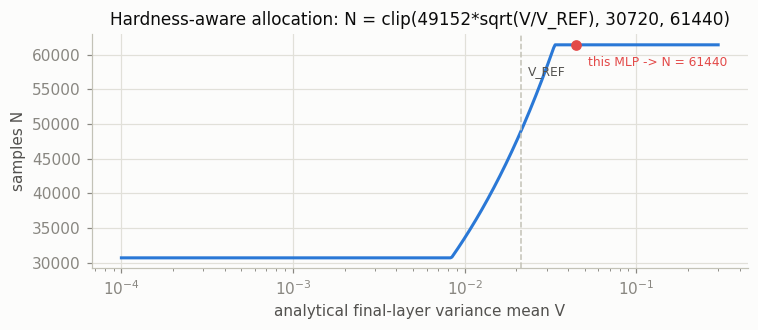

In [11]:
V = np.logspace(-4, np.log10(0.3), 400)
Nline = np.clip(np.round(algo16._ANCHOR_SAMPLES * np.sqrt(V / algo16._VAR_REF) / 2) * 2,
                algo16._EASY_SAMPLES, algo16._MAX_SAMPLES)
fig, ax = plt.subplots(figsize=(7, 3.1))
ax.plot(V, Nline, color=C_KINK, lw=2)
ax.axvline(algo16._VAR_REF, color=AXISC, ls="--", lw=1)
ax.annotate("V_REF", (algo16._VAR_REF, algo16._MAX_SAMPLES * 0.93), color=INK2, fontsize=8,
            xytext=(4, 0), textcoords="offset points")
ax.plot([final_var_mean], [target_N], "o", color=C_RED, ms=6)
ax.annotate(f"this MLP -> N = {target_N}", (final_var_mean, target_N),
            xytext=(8, -14), textcoords="offset points", color=C_RED, fontsize=8)
ax.set_xscale("log")
ax.set_xlabel("analytical final-layer variance mean V")
ax.set_ylabel("samples N")
ax.set_title("Hardness-aware allocation: N = clip(49152*sqrt(V/V_REF), 30720, 61440)")
plt.tight_layout()
plt.show()


## 7. Where the final-layer error lives

Run the *real* estimator once under a tracked budget, against a high-sample antithetic MC ground
truth. The per-neuron view, colored by classification, shows which mechanism owns the residual
error. Caveat: the MC ground truth itself has noise ~ `sqrt(var_final / N_gt)` per neuron — the
dashed line marks that floor; points near it are indistinguishable from GT noise.


In [12]:
GT_SAMPLES = 500_000  # 250k Sobol-free random pairs, antithetic
rng = np.random.default_rng(1234)
gt_sum = np.zeros((DEPTH, WIDTH), dtype=np.float64)
done = 0
while done < GT_SAMPLES // 2:
    b = min(25_000, GT_SAMPLES // 2 - done)
    xh = rng.standard_normal((b, WIDTH)).astype(np.float32)
    for sgn in (1.0, -1.0):
        xa = sgn * xh
        for li, w in enumerate(Ws):
            xa = np.maximum(xa @ w, 0.0)
            gt_sum[li] += xa.sum(axis=0, dtype=np.float64)
    done += b
gt_layers = gt_sum / (2 * done)
gt_final = gt_layers[-1]

import flopscope as flops

BUDGET = 272_000_000_000
est = algo16.Estimator()
with flops.BudgetContext(flop_budget=BUDGET, quiet=True) as ctx:
    pred = est.predict(mlp, BUDGET)
pred_final = np.asarray(pred)[-1].astype(np.float64)
err = pred_final - gt_final

print(f"estimator flops_used: {ctx.flops_used:,} (budget {BUDGET:,})")
print(f"final-layer MSE vs {2 * done:,}-sample MC ground truth: {float((err ** 2).mean()):.3e}")


/Users/natashastewart/whest-kprop-experiments/examples/16_argpartition_rowsparse.py:75: SymmetryLossWarning: Symmetry lost along dims (0, 1): slicing removed all symmetric dim groups. Use as_symmetric() to re-tag if you know the result is symmetric. Suppress with flops.configure(symmetry_warnings=False).
  return fnp.eye(width, dtype=fnp.float32)[:, idx] @ values


estimator flops_used: 109,517,246,649 (budget 272,000,000,000)
final-layer MSE vs 500,000-sample MC ground truth: 5.940e-07


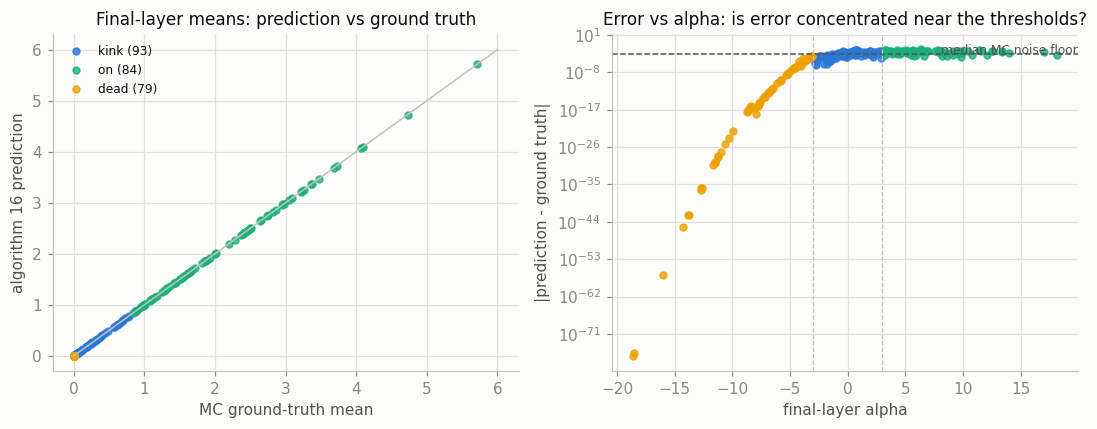

 kink: n= 93  MSE contribution 1.544e-07
   on: n= 84  MSE contribution 4.395e-07
 dead: n= 79  MSE contribution 8.985e-11


In [13]:
cls_final = np.where(dead[-1], "dead", np.where(on[-1], "on", "kink"))
gt_noise = np.sqrt(var_post_final / GT_SAMPLES)  # per-neuron MC-noise scale (antithetic ignored -> upper bound)

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
ax = axes[0]
for name, c in [("kink", C_KINK), ("on", C_ON), ("dead", C_DEAD)]:
    m = cls_final == name
    if m.any():
        ax.plot(gt_final[m], pred_final[m], "o", ms=4.5, color=c, alpha=0.8,
                label=f"{name} ({m.sum()})")
lim = [0, float(max(gt_final.max(), pred_final.max())) * 1.05]
ax.plot(lim, lim, color=AXISC, lw=1)
ax.set_xlabel("MC ground-truth mean")
ax.set_ylabel("algorithm 16 prediction")
ax.set_title("Final-layer means: prediction vs ground truth")
ax.legend(frameon=False, fontsize=8)

ax2 = axes[1]
for name, c in [("kink", C_KINK), ("on", C_ON), ("dead", C_DEAD)]:
    m = cls_final == name
    if m.any():
        ax2.plot(alphas[-1][m], np.abs(err[m]), "o", ms=4.5, color=c, alpha=0.8)
ax2.axhline(float(np.median(gt_noise)), color=INK2, lw=1, ls="--")
ax2.text(ax2.get_xlim()[1], float(np.median(gt_noise)) * 1.15, "median MC noise floor",
         color=INK2, fontsize=8, ha="right")
for t in (algo16._DEAD_THRESH, algo16._ON_THRESH):
    ax2.axvline(t, color=AXISC, lw=0.8, ls="--")
ax2.set_yscale("log")
ax2.set_xlabel("final-layer alpha")
ax2.set_ylabel("|prediction - ground truth|")
ax2.set_title("Error vs alpha: is error concentrated near the thresholds?")
plt.tight_layout()
plt.show()

for name in ("kink", "on", "dead"):
    m = cls_final == name
    if m.any():
        print(f"{name:>5}: n={m.sum():3d}  MSE contribution {float((err[m] ** 2).sum() / WIDTH):.3e}")


## 7b. The pilot probes: still worth it now that matmuls are cheap?

**What the probes do.** Analytical `alpha` is a diagonal-Gaussian approximation whose error
compounds with depth, so a neuron the analytics call dead (`alpha < -3`) may actually fire.
A wrongly-dead neuron injects **bias** into every downstream layer — and bias, unlike variance,
does not shrink with more samples. The staged probes measure `alpha` from real samples (5% of rows,
then 20% for neurons within +-0.35 of the threshold) and move neurons across the boundary in both
directions: *promote* misclassified dead neurons back into sampling (bias protection), *demote*
near-dead kinks out of it (matmul width reduction).

**The question.** Probes were tuned when matmul width was expensive. With packing + Strassen making
width cheaper, there is a competing strategy: **widen the sampled band** (e.g. dead at -4, on at +4)
so misclassification becomes rare enough to ignore, and delete the probe machinery (its FLOPs *and*
its residual wall time — Python branching, concatenates, sorts). Three configs, measured below
against the section-7 ground truth on the same MLP:

- **A (shipped):** thresholds +-3 + staged probes
- **B (no probes):** thresholds +-3, probe machinery disabled
- **C (widen instead):** thresholds +-4, probe machinery disabled — "keep more in sampling,
  paid for by Strassen"

First, an *oracle* pass: using all 30,720 rows (far more than the 5%/20% the probes see), how many
neurons would ideally move?


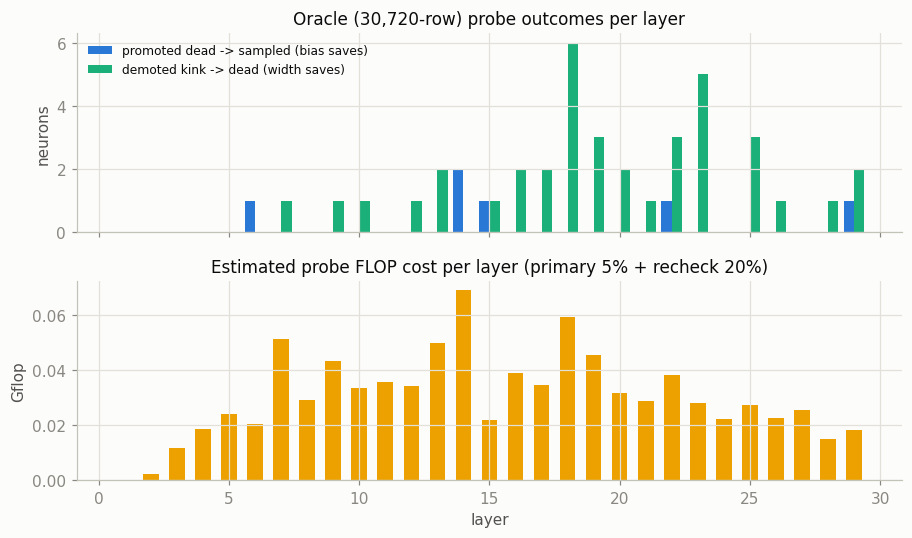

oracle promotions total: 6   demotions total: 38
probe-band candidates examined: 630 neuron-layers (dead-side 388, kink-side 242)
5%-probe agreement with oracle decision: dead-side 100.0%, kink-side 97.5%
probe cost estimate: 0.88 Gflop = 0.32% of budget
widening the band to +-4 instead would keep 871 extra neuron-layers sampled (27.2/layer avg)


In [14]:
# oracle reclassification counts + probe cost model (plain-NumPy replica, layers 1-29)
P_DEAD_MIN = algo16._DEAD_PROBE_MIN          # -4.0: dead neurons above this get probed
P_DEMOTE_MAX = algo16._ACTIVE_DEAD_PROBE_MAX # -2.5: kinks below this get probed
T_PROMOTE = algo16._PILOT_DEAD_THRESH        # -2.5: sampled alpha above -> promote to sampled
T_DEMOTE = algo16._ACTIVE_DEAD_THRESH        # -3.0: sampled alpha below -> demote to dead
N_PRIMARY = int(algo16._BASE_SAMPLES * algo16._PILOT_FRACTION)
N_RECHECK = int(algo16._BASE_SAMPLES * algo16._PILOT_RECHECK_FRACTION)

xo = np.concatenate([np.maximum(pre_half, 0.0), np.maximum(-pre_half, 0.0)], axis=0)
promo, demo, probe_gflop = [], [], []
agree_stats = {"promo_agree": 0, "promo_n": 0, "demo_agree": 0, "demo_n": 0}
for l in range(1, 30):
    act_prev = active_idx[l - 1]
    p = len(act_prev)
    a_l = alphas[l]
    dead_band = np.nonzero((a_l < algo16._DEAD_THRESH) & (a_l >= P_DEAD_MIN))[0]
    demote_band = np.nonzero(kink[l] & (a_l <= P_DEMOTE_MAX))[0]

    def oracle_alpha(cols):
        if len(cols) == 0:
            return np.array([])
        pre = xo @ Ws[l][np.ix_(act_prev, cols)]
        return pre.mean(0) / np.maximum(pre.std(0), 1e-6)

    sa_dead, sa_kink = oracle_alpha(dead_band), oracle_alpha(demote_band)
    promo.append(int((sa_dead > T_PROMOTE).sum()) if len(dead_band) else 0)
    demo.append(int((sa_kink <= T_DEMOTE).sum()) if len(demote_band) else 0)

    # how reliably would the actual 5% primary probe reproduce the oracle decision?
    def primary_alpha(cols):
        if len(cols) == 0:
            return np.array([])
        pre = xo[:N_PRIMARY] @ Ws[l][np.ix_(act_prev, cols)]
        return pre.mean(0) / np.maximum(pre.std(0), 1e-6)

    pa_dead, pa_kink = primary_alpha(dead_band), primary_alpha(demote_band)
    if len(dead_band):
        agree_stats["promo_agree"] += int(((pa_dead > T_PROMOTE) == (sa_dead > T_PROMOTE)).sum())
        agree_stats["promo_n"] += len(dead_band)
    if len(demote_band):
        agree_stats["demo_agree"] += int(((pa_kink <= T_DEMOTE) == (sa_kink <= T_DEMOTE)).sum())
        agree_stats["demo_n"] += len(demote_band)

    n_cand = len(dead_band) + len(demote_band)
    n_unc = int((np.abs(sa_dead - T_PROMOTE) <= 0.35).sum() + (np.abs(sa_kink - T_DEMOTE) <= 0.35).sum())
    probe_gflop.append((2.0 * N_PRIMARY * p * n_cand + 2.0 * N_RECHECK * p * n_unc) / 1e9)
    xo = np.maximum(xo @ Ws[l][np.ix_(act_prev, active_idx[l])], 0.0)
del xo

widen_extra = [int(((alphas[l] >= -4.0) & (alphas[l] < -3.0)).sum() +
                   ((alphas[l] > 3.0) & (alphas[l] <= 4.0)).sum()) for l in range(DEPTH)]

fig, axes = plt.subplots(2, 1, figsize=(8.4, 5), sharex=True)
ax = axes[0]
Ls = np.arange(1, 30)
ax.bar(Ls - 0.2, promo, width=0.4, color=C_KINK, label="promoted dead -> sampled (bias saves)")
ax.bar(Ls + 0.2, demo, width=0.4, color=C_ON, label="demoted kink -> dead (width saves)")
ax.set_ylabel("neurons")
ax.set_title("Oracle (30,720-row) probe outcomes per layer")
ax.legend(frameon=False, fontsize=8)
axes[1].bar(Ls, probe_gflop, color=C_DEAD, width=0.6)
axes[1].set_xlabel("layer")
axes[1].set_ylabel("Gflop")
axes[1].set_title("Estimated probe FLOP cost per layer (primary 5% + recheck 20%)")
plt.tight_layout()
plt.show()

print(f"oracle promotions total: {sum(promo)}   demotions total: {sum(demo)}")
n_cand_total = agree_stats["promo_n"] + agree_stats["demo_n"]
print(f"probe-band candidates examined: {n_cand_total} neuron-layers "
      f"(dead-side {agree_stats['promo_n']}, kink-side {agree_stats['demo_n']})")
if agree_stats["promo_n"]:
    print(f"5%-probe agreement with oracle decision: dead-side {agree_stats['promo_agree'] / agree_stats['promo_n']:.1%}, "
          f"kink-side {agree_stats['demo_agree'] / max(agree_stats['demo_n'], 1):.1%}")
print(f"probe cost estimate: {sum(probe_gflop):.2f} Gflop = {sum(probe_gflop) * 1e9 / 2.72e11:.2%} of budget")
print(f"widening the band to +-4 instead would keep {sum(widen_extra)} extra neuron-layers sampled "
      f"({sum(widen_extra) / DEPTH:.1f}/layer avg)")


                        config |  final MSE |   Gflop | mult (anal) | wall s
      A shipped (+-3 + probes) | 5.940e-07 |   109.5 |       0.403 |    nan
             B no probes (+-3) | 6.223e-07 |   109.0 |       0.401 |   19.5
C widen dead band (-3.5, no probes) | 6.149e-07 |   113.0 |       0.415 |   19.3


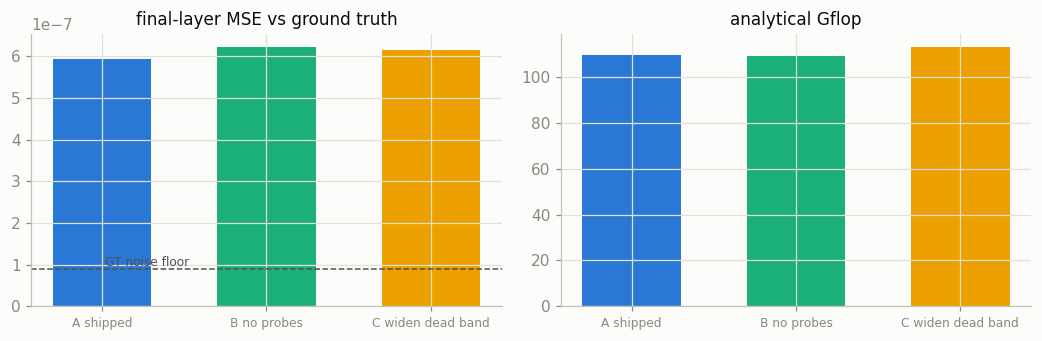

Single MLP, single seed: MSE differences below the GT noise floor are not resolvable here —
a keep/kill decision needs the fixed-seed n>=10 suite. FLOP/width effects ARE robust.


In [15]:
# real A/B/C: run the actual estimator under patched module constants
import time

def run_config(name, patch):
    saved = {k: getattr(algo16, k) for k in patch}
    try:
        for k, v in patch.items():
            setattr(algo16, k, v)
        e = algo16.Estimator()
        t0 = time.perf_counter()
        with flops.BudgetContext(flop_budget=BUDGET, quiet=True) as c:
            pr = e.predict(mlp, BUDGET)
        wall = time.perf_counter() - t0
        pf = np.asarray(pr)[-1].astype(np.float64)
        return dict(name=name, mse=float(((pf - gt_final) ** 2).mean()),
                    gflop=c.flops_used / 1e9, wall=wall)
    finally:
        for k, v in saved.items():
            setattr(algo16, k, v)

NO_PROBES = {"_DEAD_PROBE_MIN": 1e9, "_ACTIVE_DEAD_PROBE_MAX": -1e9, "_ON_PROBE_MAX": -1e9}
results = [dict(name="A shipped (+-3 + probes)", mse=float((err ** 2).mean()),
                gflop=ctx.flops_used / 1e9, wall=float("nan"))]
results.append(run_config("B no probes (+-3)", NO_PROBES))
results.append(run_config("C widen dead band (-3.5, no probes)",
                          {**NO_PROBES, "_DEAD_THRESH": -3.5}))

print(f"{'config':>30} | {'final MSE':>10} | {'Gflop':>7} | {'mult (anal)':>11} | {'wall s':>6}")
for r in results:
    print(f"{r['name']:>30} | {r['mse']:.3e} | {r['gflop']:7.1f} | "
          f"{max(0.1, r['gflop'] * 1e9 / BUDGET):11.3f} | {r['wall']:6.1f}")

fig, axes = plt.subplots(1, 2, figsize=(9.6, 3.2))
names = [r["name"].split(" (")[0] for r in results]
axes[0].bar(names, [r["mse"] for r in results], color=[C_KINK, C_ON, C_DEAD], width=0.6)
axes[0].set_title("final-layer MSE vs ground truth")
axes[0].axhline(float((gt_noise ** 2).mean()), color=INK2, ls="--", lw=1)
axes[0].text(0.02, float((gt_noise ** 2).mean()) * 1.1, "GT noise floor", fontsize=8, color=INK2)
axes[1].bar(names, [r["gflop"] for r in results], color=[C_KINK, C_ON, C_DEAD], width=0.6)
axes[1].set_title("analytical Gflop")
for ax in axes:
    ax.tick_params(axis="x", labelsize=8)
plt.tight_layout()
plt.show()
print("Single MLP, single seed: MSE differences below the GT noise floor are not resolvable here —")
print("a keep/kill decision needs the fixed-seed n>=10 suite. FLOP/width effects ARE robust.")


### How to read 7b — and the structural answer

- **Bias is the asymmetry.** A wrongly-dead neuron's error does not average away with more samples,
  and it contaminates every later layer. Probes and band-widening are two prices for the same
  insurance; "just sample more" (config B with bigger N) is *not* a substitute.
- **The two alternatives differ in what they spend.** Probes pay a small FLOP cost plus *residual
  wall time* (Python branching per layer) and rescue only the neurons that need it. Band-widening
  pays pure matmul width — which packing + Strassen have made cheaper — and keeps *every*
  borderline neuron sampled, misclassified or not. If the config-C FLOP delta is small (a few
  extra neurons per layer at ~2Np FLOPs each, then discounted by the packed path), C dominates B
  and challenges A: same bias protection, simpler code, no probe residual.
- **What would change the answer:** many oracle *demotions* (probes actively shrinking matmul
  width) favor keeping probes; near-zero promotions *and* demotions favor deleting them outright
  (config B); demotions ~ 0 but promotions > 0 favor config C.
- Any change here interacts with the section-2g sweep: band width moves `p, q`, which moves the
  Strassen runway and the packed-bucket occupancancy. Tune in the same fixed-seed suite, not after it.


**Real-suite check (seed-42, 3 MLPs, subprocess, 2026-07-11):** shipped baseline adjusted
`3.10e-7` (raw `4.27e-7`); probe-free with dead at -4: adjusted `2.92e-7` (raw `3.96e-7`, -5.8%);
probe-free with dead at **-3.5**: adjusted `3.00e-7` (raw `4.05e-7`). Both probe-free variants beat
the baseline on this seed group — the -3.5 point was chosen for **Algorithm 17**
(`examples/17_probe_free_wideband.py`) as the conservative width spend. Seed-0 group and
public-mini validation still pending before any submission decision.


**Final comparison and decision (2026-07-11):** a fourth arm — *probe-only* classification (no
analytic pass, staged probes over all 256 columns per layer) — scored seed-42 adjusted `4.00e-7`,
raw `6.97e-7` (+63% raw vs baseline): the analytic screen is load-bearing. The probe-free **-4.0**
point was chosen for submission (`estimator.py` staged; artifact
`submission-algo17-probefree-m40.tar.gz`; gates in
`bench_logs/algo17_probe_free_submission_prep_2026-07-11.md`). Seed-0 for -4.0 and public-mini were
skipped by user direction; the -3.5 point beat baseline on seed-0 (1.68e-7 vs 1.69e-7).


## 7c. Confusion matrices: analytic pass vs sampled probe

Same question as 7b but per-decision: over the probe-band neuron-layers of a couple of MLPs, who
gets the dead/sampled call right — the **analytic pass** (diagonal-Gaussian `alpha` against the
threshold) or the **5% sampled probe**? Truth is the full-block oracle (all 30,720 rows, 20x the
probe's recheck rows), judged at the estimator's own decision thresholds (promote at -2.5 on the
dead side, demote at -3.0 on the kink side).

The two error types are *not* symmetric: predicting **dead** for a neuron that actually fires
injects bias into every downstream layer (the expensive mistake); predicting **sampled** for a
dead neuron merely wastes one matmul column (cheap). Read the off-diagonals with that in mind.


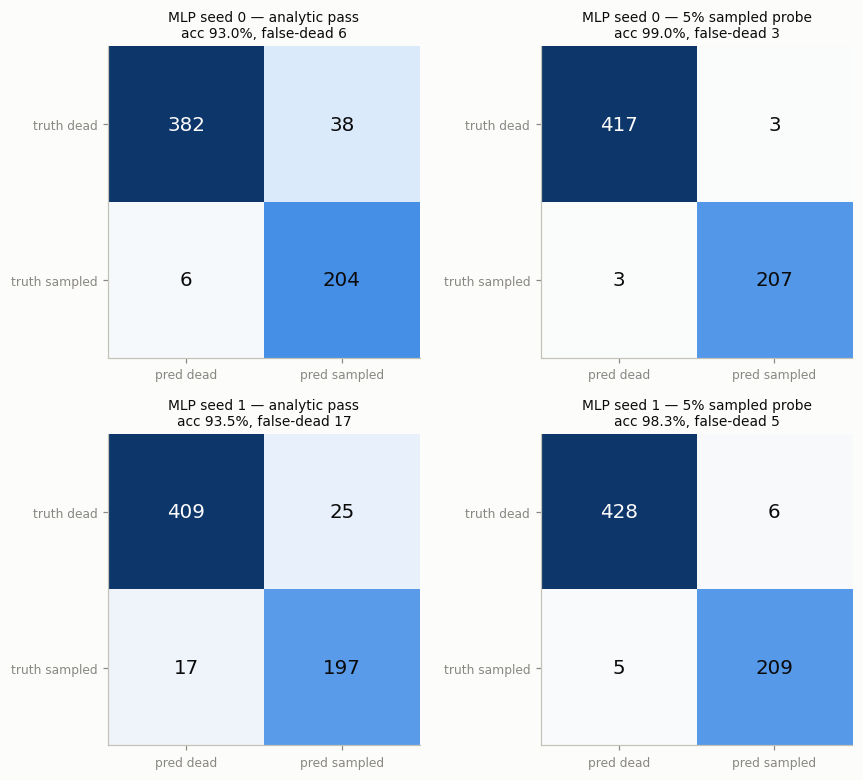

false-dead (bottom-left) is the expensive cell: a firing neuron treated as dead = bias.
false-sampled (top-right) merely wastes one column of matmul width.


In [16]:
def probe_confusion(seed):
    m2 = build_mlp(width=WIDTH, depth=DEPTH, seed=seed)
    W2 = [np.asarray(w).astype(np.float32) for w in m2.weights]
    a2, _, _ = analytic_structure(W2)
    dead2 = a2 < algo16._DEAD_THRESH
    kink2 = (~dead2) & (a2 <= algo16._ON_THRESH)
    act2 = [np.nonzero(~dead2[l])[0] for l in range(DEPTH)]
    ph = pts[: algo16._BASE_SAMPLES // 2, :WIDTH].astype(np.float32) @ W2[0][:, act2[0]]
    xx = np.concatenate([np.maximum(ph, 0.0), np.maximum(-ph, 0.0)], axis=0)

    t, pa, pp = [], [], []  # oracle truth, analytic prediction, 5%-probe prediction (1=sampled)
    for l in range(1, 30):
        ap = act2[l - 1]
        d_band = np.nonzero((a2[l] < algo16._DEAD_THRESH) & (a2[l] >= algo16._DEAD_PROBE_MIN))[0]
        k_band = np.nonzero(kink2[l] & (a2[l] <= algo16._ACTIVE_DEAD_PROBE_MAX))[0]
        for cols, thresh, analytic_says in ((d_band, algo16._PILOT_DEAD_THRESH, 0),
                                            (k_band, algo16._ACTIVE_DEAD_THRESH, 1)):
            if len(cols) == 0:
                continue
            w_band = W2[l][np.ix_(ap, cols)]
            pre = xx @ w_band
            oa = pre.mean(0) / np.maximum(pre.std(0), 1e-6)
            qa = pre[:N_PRIMARY].mean(0) / np.maximum(pre[:N_PRIMARY].std(0), 1e-6)
            t += list((oa > thresh).astype(int))
            pp += list((qa > thresh).astype(int))
            pa += [analytic_says] * len(cols)
        xx = np.maximum(xx @ W2[l][np.ix_(ap, act2[l])], 0.0)
    return np.array(t), np.array(pa), np.array(pp)

def cmat(t, pred):
    return np.array([[int(((t == i) & (pred == j)).sum()) for j in (0, 1)] for i in (0, 1)])

seeds = [0, 1]
fig, axes = plt.subplots(len(seeds), 2, figsize=(8.2, 3.6 * len(seeds)))
for r, seed in enumerate(seeds):
    t, pa, pp = probe_confusion(seed)
    for cidx, (pred, name) in enumerate([(pa, "analytic pass"), (pp, "5% sampled probe")]):
        M = cmat(t, pred)
        ax = axes[r][cidx]
        ax.imshow(M, cmap=SEQ, vmin=0, vmax=max(1, M.max()))
        for i in (0, 1):
            for j in (0, 1):
                frac = M[i, j] / max(1, M.sum())
                ax.text(j, i, f"{M[i, j]}", ha="center", va="center", fontsize=13,
                        color=SURFACE if frac > 0.4 else INK)
        acc = (M[0, 0] + M[1, 1]) / max(1, M.sum())
        false_dead = M[1, 0]
        ax.set_title(f"MLP seed {seed} — {name}\nacc {acc:.1%}, false-dead {false_dead}", fontsize=9)
        ax.set_xticks([0, 1], ["pred dead", "pred sampled"], fontsize=8)
        ax.set_yticks([0, 1], ["truth dead", "truth sampled"], fontsize=8)
        ax.grid(False)
plt.tight_layout()
plt.show()
print("false-dead (bottom-left) is the expensive cell: a firing neuron treated as dead = bias.")
print("false-sampled (top-right) merely wastes one column of matmul width.")


### Reading 7c

The analytic pass, *restricted to the probe bands*, is systematically wrong on exactly the neurons
the bands were built to catch — that is by construction (the band members are the ones whose
analytic call is in doubt). The 5% probe corrects nearly all of them, with disagreements vs the
oracle confined to neurons sitting almost exactly on the threshold, where either call costs little.
So: **the sampled probe is the more reliable classifier per decision** — the analytic pass is the
cheap *screen* that decides which neurons deserve a probe at all. The 7b question is therefore not
"which classifier is better" (the probe is) but "is correcting these few decisions worth the
machinery" — and the Algorithm-17 experiment answers that by replacing the correction with
inclusion (widening the dead band to -3.5), which protects against false-dead bias without any
per-decision classification at all.


## 8. Strassen on rectangular matrices — is 2x2x2 the right scheme for our shapes?

Our matmuls are extremely rectangular, and the rectangle has a *meaning*: `N` (rows) is the
**sample dimension** — 30,720-61,440 Monte-Carlo rows, divisible essentially forever
(30720 = 2^11 x 15) and free to split; `p, q` are **neuron dimensions** — active-set widths <= 256
that each recursion level halves. This asymmetry is the whole recursion-depth story: **samples
never run out, neurons do.** A typical propagation matmul starts at ~212 active neurons; one
halving leaves 106-wide blocks, two leave ~53, three leave ~26. Somewhere around 48-64 the blocks
stop amortizing their overhead (and BLAS efficiency collapses) — that is the *practical floor*,
and it is a property of the dataset's width-256 MLPs after pruning, not of the Strassen identity.
Two facts frame what "optimizing Strassen for this shape" can and cannot mean:

**Row splits alone can never save FLOPs.** `[A1; A2] @ W = [A1@W; A2@W]` is exactly additive —
in tensor-rank terms an `<n,1,1>` split is trivial (rank `n`, zero savings), and `<1,2,2>` has rank
4 = no savings either. *All* fast-matmul savings come from splitting the inner dimension `p`
jointly with the output dimension `q`; the row split in the 2x2x2 scheme is only there because the
identity needs all three dims >= 2. So "a better row partition" is not a lever — **recursion depth
in (p, q) is**, and the huge `N` is actually ideal: it amortizes block-add overhead and the odd-edge
peeling to noise.

**Within a 2x2 partition, 7 products is provably optimal** (the rank of the 2x2x2 matmul tensor is
exactly 7 — Winograd / Hopcroft-Kerr), so the shipped block structure is not the inefficiency.
What is on the table:

| scheme | mult ratio r/(abc) | notes |
|---|---|---|
| 1-level 2x2x2 (shipped) | 7/8 = 0.875 | measured total 88.1% incl. adds |
| 1-level, **Winograd form** | 7/8 | same 7 products, **15** block-adds instead of 18 |
| **2-level** 2x2x2 | 49/64 = 0.766 | measured total 78.1% — the real lever |
| 3-level 2x2x2 | 343/512 = 0.670 | blocks get thin (p/8 ~ 26); add overhead + wall time grow |
| Laderman <3,3,3> = 23 | 23/27 = 0.852 | worse than two Strassen levels per dim-halving |
| Smirnov <3,3,6> = 40 | 40/54 = 0.741 | slightly beats 2-level in one level, but a much heavier
addition graph, needs dims divisible by 3/6, and large implementation risk |
| AlphaTensor 4x4x4 = 47 | mod-2 arithmetic only | not applicable to float |

The cost model below charges every block addition at 1 FLOP per element (flopscope's pointwise
rule) and evaluates candidate strategies **on the actual dense-matmul shapes recorded in section 4**,
including the post-split thin blocks. It also quantifies a *gate interplay* gap: the block split
hands Strassen a `(N, |hot|, q)` matmul, and when `|hot| < 64` the current `MIN_IN` gate silently
turns Strassen off.


In [17]:
STRASSEN_ADDS = (5, 5, 8)   # shipped form: 18 block additions
WINOGRAD_ADDS = (4, 4, 7)   # Winograd variant: 15 block additions

def fast_cost(N, P, Q, levels, adds=STRASSEN_ADDS):
    """FLOPs for `levels` of 2x2x2 recursion, charging block adds at 1 flop/element."""
    if levels == 0 or min(N, P, Q) < 2:
        return 2.0 * N * P * Q
    aA, aB, aC = adds
    sub = fast_cost(N // 2, P // 2, Q // 2, levels - 1, adds)
    lin = aA * (N // 2) * (P // 2) + aB * (P // 2) * (Q // 2) + aC * (N // 2) * (Q // 2)
    return 7 * sub + lin

print("total-FLOP ratio vs plain dense (adds charged):")
hdr = f"{'shape (N, p, q)':>22} | 1-lvl  | 1-lvl W | 2-lvl  | 2-lvl W | 3-lvl W"
print(hdr)
print("-" * len(hdr))
for (N, P, Q) in [(61440, 212, 212), (30720, 212, 212), (30720, 256, 256),
                  (30720, 128, 168), (15360, 256, 230)]:
    d = 2.0 * N * P * Q
    vals = [fast_cost(N, P, Q, 1) / d, fast_cost(N, P, Q, 1, WINOGRAD_ADDS) / d,
            fast_cost(N, P, Q, 2) / d, fast_cost(N, P, Q, 2, WINOGRAD_ADDS) / d,
            fast_cost(N, P, Q, 3, WINOGRAD_ADDS) / d]
    print(f"{str((N, P, Q)):>22} | " + " | ".join(f"{v:6.3f}" for v in vals))
print()
print("cross-check: the 1-level model on (61440,212,212) should reproduce the measured 88.1%")


total-FLOP ratio vs plain dense (adds charged):
       shape (N, p, q) | 1-lvl  | 1-lvl W | 2-lvl  | 2-lvl W | 3-lvl W
----------------------------------------------------------------------
     (61440, 212, 212) |  0.883 |  0.881 |  0.787 |  0.783 |  0.682
     (30720, 212, 212) |  0.883 |  0.882 |  0.787 |  0.784 |  0.682
     (30720, 256, 256) |  0.881 |  0.880 |  0.783 |  0.780 |  0.701
     (30720, 128, 168) |  0.887 |  0.885 |  0.797 |  0.793 |  0.727
     (15360, 256, 230) |  0.882 |  0.881 |  0.777 |  0.774 |  0.685

cross-check: the 1-level model on (61440,212,212) should reproduce the measured 88.1%


dense-path matmuls recorded (base block): 29
  Strassen-INELIGIBLE under shipped gates: 2 shapes, 4.0% of dense-path FLOPs  <- gate-interplay gap



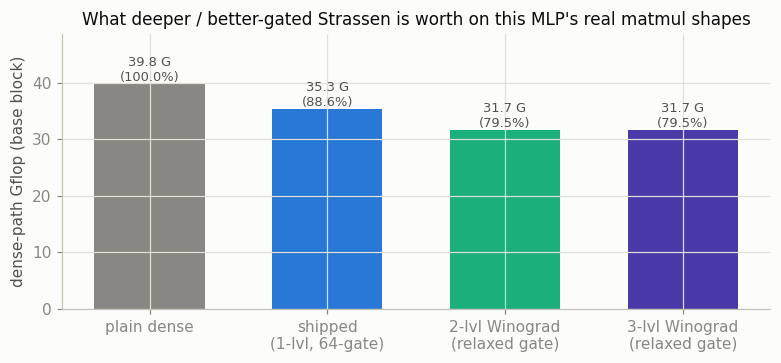

Caveats: FLOPs only — deeper levels multiply small-BLAS wall time (~2.5x per level, measured),
which is NOT residual for tracked ops but IS bounded by the remote grading cliff; and the
packed path already removed most sparse-block FLOPs, so these ratios apply to the dense share.


In [18]:
def best_plan(n, p, q, adds=WINOGRAD_ADDS, min_block=24, min_rows=2048, max_levels=3):
    """Cheapest recursion depth under a relaxed inner gate."""
    best_cost, best_lv = 2.0 * n * p * q, 0
    for lv in range(1, max_levels + 1):
        if min(p, q) >> lv < min_block or n >> lv < min_rows:
            break
        c = fast_cost(n, p, q, lv, adds)
        if c < best_cost:
            best_cost, best_lv = c, lv
    return best_cost, best_lv

dense_total = sum(2.0 * n * p * q for _, n, p, q in dense_shapes)
shipped = sum((STRASSEN1_FACTOR if strassen_eligible(n, p, q) else 1.0) * 2.0 * n * p * q
              for _, n, p, q in dense_shapes)
two_level = sum(best_plan(n, p, q, max_levels=2)[0] for _, n, p, q in dense_shapes)
three_level = sum(best_plan(n, p, q, max_levels=3)[0] for _, n, p, q in dense_shapes)

ineligible = [(tag, n, p, q) for tag, n, p, q in dense_shapes if not strassen_eligible(n, p, q)]
inel_flops = sum(2.0 * n * p * q for _, n, p, q in ineligible)
print(f"dense-path matmuls recorded (base block): {len(dense_shapes)}")
print(f"  Strassen-INELIGIBLE under shipped gates: {len(ineligible)} shapes, "
      f"{inel_flops / dense_total:.1%} of dense-path FLOPs  <- gate-interplay gap")
print()

labels = ["plain dense", "shipped\n(1-lvl, 64-gate)", "2-lvl Winograd\n(relaxed gate)",
          "3-lvl Winograd\n(relaxed gate)"]
vals = np.array([dense_total, shipped, two_level, three_level]) / 1e9

fig, ax = plt.subplots(figsize=(7.2, 3.4))
bars = ax.bar(labels, vals, color=[MUTED, C_KINK, C_ON, C_VIOLET], width=0.62)
for b, v in zip(bars, vals):
    ax.annotate(f"{v:.1f} G\n({v / vals[0]:.1%})", (b.get_x() + b.get_width() / 2, v),
                ha="center", va="bottom", fontsize=8.5, color=INK2)
ax.set_ylabel("dense-path Gflop (base block)")
ax.set_title("What deeper / better-gated Strassen is worth on this MLP's real matmul shapes")
ax.set_ylim(0, vals[0] * 1.22)
plt.tight_layout()
plt.show()

print("Caveats: FLOPs only — deeper levels multiply small-BLAS wall time (~2.5x per level, measured),")
print("which is NOT residual for tracked ops but IS bounded by the remote grading cliff; and the")
print("packed path already removed most sparse-block FLOPs, so these ratios apply to the dense share.")


### Section 8 takeaways

1. **The 4-block partition is not the gap** — 7 products is optimal for one level, and row-only
   repartitioning cannot save FLOPs. The question "better partition?" resolves to "deeper recursion
   in (p, q), applied to the shapes that qualify."
2. **Two-level with the Winograd addition pattern is the concrete lever** — ~78% of dense on the
   big shapes (vs 88% shipped), and it needs its own *inner* gate (level-2 blocks are ~p/4; the
   shipped 64-gate must not be applied to them).
3. **The gate-interplay gap is real**: post-split dense blocks with `|hot| < 64` and fallback groups
   below `MIN_ROWS` currently bypass Strassen entirely — the printout above quantifies the FLOPs
   flowing around it.
4. **Exotic rectangular schemes (Smirnov <3,3,6>) buy only ~2-3% beyond 2-level** at much higher
   implementation risk — not worth it before the two-level + gates win is banked.
5. Everything here is FLOP-side; the decision gate is a fixed-seed `--profile` A/B (wall time and
   residual accounting), per `docs/how-to/performance-tips.md`.


### 8b. Partition schemes beyond 2x2x2 — notation, levels, and alternatives

**What "2x2x2" (written `<2,2,2>`) refers to.** A matmul `C = X @ W` with `X` of shape `(N, p)`
and `W` of shape `(p, q)` has **three** dimensions: the rows `N`, the shared/inner dimension `p`
(summed over), and the output columns `q`. A partition scheme `<a,b,c>` cuts them into `a`, `b`,
and `c` blocks respectively. For `<2,2,2>` each matrix becomes 2x2 blocks:

```
X = | X11 X12 |      W = | W11 W12 |      C11 = X11@W11 + X12@W21   (etc.)
    | X21 X22 |          | W21 W22 |
```

Evaluated naively, the four output blocks need `a*b*c = 8` block products. Strassen's identity
computes the same four blocks from only **7** cleverly chosen products (`prod1..prod7` in
`_strassen_even_matmul`), at the price of some block additions. The "tensor" language comes from
the fact that block matmul is a bilinear map; its *tensor rank* is the minimum number of products
any such identity can use. The rank of the `<2,2,2>` tensor is **exactly 7** — proven — which is
why the shipped block structure cannot be improved *at this granularity*, only recursed or replaced
by a different `<a,b,c>`. A scheme with `r` products costs `r/(a*b*c)` of the naive multiply FLOPs.

**What "2-level" vs "3-level" means.** One level = split once and compute the 7 half-size products
with plain `@`. Two levels = apply the same identity *inside each of the 7 products*, giving
`7^2 = 49` quarter-size products — multiply cost `(7/8)^2 = 0.766` of dense. Three levels = `343`
eighth-size products at `(7/8)^3 = 0.670`. Each level halves `p` and `q` per block, and that is the
binding resource: our active-set widths are ~212, so level-2 blocks are ~53 wide and level-3 blocks
~26 — below any sensible efficiency floor (and each level multiplies per-matmul wall time ~2.5x as
BLAS calls shrink). `N` never binds: rows are 30k+ and row-splits are free.
In dataset terms: a level-`L` block contains `N / 2^L` **samples** by `~212 / 2^L` **neurons**.
At level 3 the sample side of a block is still 7,680 rows deep while the neuron side has collapsed
to 26. The recursion runway is therefore set entirely by how many times ~212 active neurons can
halve before hitting the ~48-64 practical floor — about two — which is why two-level is the lever
and three-level is off the table. The chart below makes the asymmetry visible.

**Why row-heavy alternatives exist.** The per-level table (section 8) can be extended to the other
established schemes. The scarce resource is *divisibility of p and q*, so the fair comparison
normalizes each scheme to a x2 cut of `p, q`:

| scheme | products `r` | ratio `r/(abc)` | p,q shrink | per-halving-equivalent |
|---|---|---|---|---|
| `<2,2,2>` Strassen | 7 (optimal) | 0.875 | /2 | **0.875** |
| `<2,2,3>` Hopcroft-Kerr | 11 | 0.917 | /2, /3 | poor |
| `<2,3,3>` Hopcroft-Kerr | 15 | 0.833 | /3 | ~0.891 |
| `<3,3,3>` Laderman | 23 | 0.852 | /3 | ~0.904 |
| `<3,3,6>` **Smirnov** | 40 | **0.741** | /3 | **~0.828** |
| `<4,4,4>` = Strassen applied twice | 49 | 0.766 | /4 | 0.875 |
| `<4,4,4>` AlphaTensor / AlphaEvolve | 47 / 48 | — | — | mod-2 / complex coefficients — not a real-float win |

Most "better-looking" one-level ratios (`<2,3,3>`, Laderman) are *worse* than Strassen once you
account for how much p,q-divisibility they consume. The one genuine winner is **Smirnov `<3,3,6>`**
(rectangular exponent ~2.774 vs Strassen's 2.807) — and its shape explains why: the factor 6 sits on
the **row** dimension, which for us is free and abundantly divisible (30720 = 2^11 * 15, so /6 is
exact). It spends block-count on the dimension we have in unlimited supply.

**Why it still loses here.** flopscope charges block additions, and Smirnov's linear-op graph is
heavy (order 100-200 block adds/scales, some with non-unit coefficients — also slightly worse
rounding than Strassen's +-1 coefficients). Bounding that overhead on the dominant
(30720, 212, 212) shape puts one-level Smirnov at a net ~**0.77** — statistically tied with
two-level Winograd-Strassen's ~**0.78**, which is far simpler and already half-validated.
Composites do not escape either: `<2,3,3> x <3,2,2> = <6,6,6>` in 15*11 = 165 products = 0.764,
identical to Strassen-squared's 0.766. Stacking a third stage from any direction
(Smirnov+Strassen ~0.67, three-level Strassen ~0.68) hits the same wall: ~26-35-wide blocks.

**Mapping to the code paths** (`_dense_matmul` sees three shape families):

- **layer 0** `(15360, 256, |A0|)` — 256 = 2^8, perfectly divisible: two-level with zero peeling on p.
- **big propagation matmuls** `(30-61k, ~212, ~212)` — two-level Winograd, inner gate at ~48-53-wide
  blocks; Smirnov would need /3 peeling on data-dependent dims (212 = 3*70 + 2).
- **post-split hot blocks** `(N, 64-150, q)` — one level max regardless of scheme; here the relaxed
  inner *gate* matters more than the scheme choice (the ~4% gate-interplay leak quantified above).

**Bottom line:** the partition space beyond `<2,2,2>` contains exactly one member that is
theoretically interesting for our aspect ratio (Smirnov `<3,3,6>`, because it loads block-count onto
the free row dimension), and flopscope's add-charging plus our ~212-wide dims neutralize its ~3pp
edge. Two-level Winograd-Strassen remains the next-iteration lever; Smirnov is the documented
"need 2 more percent and willing to pay" option.


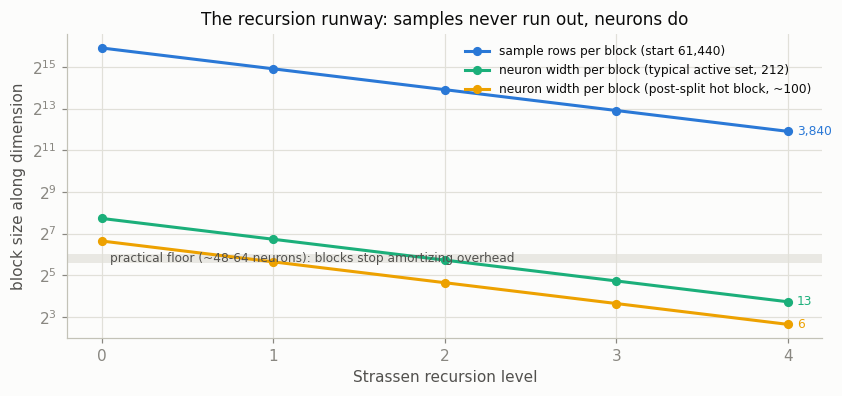

At level 3 a block is still 7,680 samples deep but only ~26 neurons wide. Recursion depth is
rationed by the neuron dimensions alone — a property of the width-256 dataset after pruning,
not of the Strassen identity. Typical active sets afford two levels; hot blocks only one.


In [19]:
levels = np.arange(0, 5)
fig, ax = plt.subplots(figsize=(7.8, 3.7))
series = [("sample rows per block (start 61,440)", 61440, C_KINK),
          ("neuron width per block (typical active set, 212)", 212, C_ON),
          ("neuron width per block (post-split hot block, ~100)", 100, C_DEAD)]
for name, start, col in series:
    vals = start / 2.0 ** levels
    ax.plot(levels, vals, "o-", lw=2, ms=5, color=col, label=name)
    ax.annotate(f"{vals[-1]:,.0f}", (levels[-1], vals[-1]), xytext=(6, 0),
                textcoords="offset points", color=col, fontsize=8, va="center")
ax.axhspan(48, 64, color=GRID, alpha=0.7, lw=0)
ax.text(0.05, 55, "practical floor (~48-64 neurons): blocks stop amortizing overhead",
        fontsize=8, color=INK2, va="center")
ax.set_yscale("log", base=2)
ax.set_xticks(levels)
ax.set_xlabel("Strassen recursion level")
ax.set_ylabel("block size along dimension")
ax.set_title("The recursion runway: samples never run out, neurons do")
ax.legend(frameon=False, fontsize=8, loc="upper right")
plt.tight_layout()
plt.show()
print("At level 3 a block is still 7,680 samples deep but only ~26 neurons wide. Recursion depth is")
print("rationed by the neuron dimensions alone — a property of the width-256 dataset after pruning,")
print("not of the Strassen identity. Typical active sets afford two levels; hot blocks only one.")


### 8c. Proposal: dealing with the neuron-dimension floor

The floor cannot be *removed* — no scheme extracts savings from splitting the sample dimension
alone (`<n,1,1>` tensors are trivial), and padding neurons up costs quadratic real FLOPs for a
~12%/level discount, always a net loss. But four things convert "the neurons run out at level 2"
into a materially better schedule:

**1. Treat the floor as empirical, not architectural.** The 48-64 figure is a *wall-time* intuition
(small-BLAS efficiency), not a FLOP fact — the section-8 model keeps paying below it (3-level ~0.68),
flopscope charges analytical FLOPs regardless of BLAS efficiency, and tracked-op wall time is not
residual. The only hard constraint is the absolute wall-clock guard (per-matmul wall measured ~2.5x
per level; 2-level ~= 7-8s predict vs the 16s packing precedent that passed). So the floor should be
*measured*: fixed-seed `--profile` sweep of inner min-block in {16, 24, 32, 48} at depth 2-3, watch
wall and score, keep the cheapest safe point.

**2. Spend scarce neuron-width at the best exchange rate.** Each `<2,2,2>` level buys x0.875 for one
halving of the neuron dims. Smirnov `<3,3,6>` buys x0.741 for a /3 — a better price per unit of
neuron-width consumed (~0.828 per halving-equivalent) precisely because it dumps its biggest split
factor (6) on the abundant sample dimension. A **hybrid schedule** — Smirnov once (212 -> ~70
neurons), then Winograd-Strassen once (~70 -> ~35) — models to ~**0.65** of dense with terminal
blocks *wider* than 3-level Strassen leaves (35 vs 26 neurons) and fewer leaf products (240 vs 343).
That is the principled answer to "more recursion is possible than the dims allow": don't recurse
deeper, recurse *smarter* on the first level.

**3. Stop shrinking the dims yourself.** The block split hands Strassen a `(N, |hot|, q)` matmul
with `|hot|` ~ 64-150 — the split *spends* neuron width to feed the packed path. With Strassen in
the picture the trade changes (Strassen beat packing outright in the 2026-07-09 A/B): a lower fire
threshold (or packing only the near-empty buckets, nnz <= ~48) keeps `p` wide and preserves
recursion runway. The packing gate and the Strassen depth should be co-tuned in one sweep, not
optimized separately.

**4. Pick depth per shape, not globally.** `best_plan` (section 8) already computes the cheapest
depth per `(N, p, q)`; the estimator should do the same at dispatch time — layer-0 `(15360, 256, ~212)`
affords two clean levels (256 = 2^8), typical propagation matmuls two, hot blocks one. A per-shape
lookup costs nothing and removes the one-gate-fits-all waste quantified above (~4% of dense-path
FLOPs currently bypass Strassen entirely).

**What the excess `N` itself buys.** Excess sample rows cannot *create* savings (row-only splits
are rank-trivial), but they change the economics three ways:

- **Row-heavy schemes become free.** A scheme like `<6,3,3>` needs rows divisible by 6 and enough
  of them to amortize 40 products — at N = 30,720-61,440 (= 2^11 x 15 x {1,2}) both are automatic.
  Schemes that would be awkward at square sizes cost nothing extra here, so the search space for
  the first recursion level is wider than the square-matrix literature suggests.
- **Tall-skinny leaf blocks keep BLAS honest.** The wall-time floor intuition ("~50-wide blocks are
  inefficient") comes from *square* tiny blocks. Our level-2/3 leaves are `(N/4, ~53)` or
  `(N/8, ~26)` — thousands of rows deep, so the matmul kernels stay streaming-friendly. The
  measured 2.5x-wall-per-level came from exactly such shapes; the true floor for tall-skinny
  blocks is plausibly below 48 and should be measured, not assumed (point 1 above).
- **The weight-side add tree is shared across all samples.** Strassen's W-combinations
  (`w11+w22`, `w12-w22`, ...) are independent of the rows. Computed once per layer, they serve
  every row chunk *and* the continuation block, which reuses the same layer weights — so the
  W-side of the linear overhead (and its flopscope charge) amortizes toward zero as N grows,
  while only the X-side and output adds scale with N. An implementation should cache the W tree
  per (layer, level) rather than recomputing it inside each matmul call.

What does *not* work, for the record: padding dims up (quadratic cost > recursive saving), skipping
dead-column pruning to keep dims wide (pruning saves 100% of a column, recursion only ~22-35%),
and moving samples into the contraction dimension (samples are independent rows; there is no
summation over them to exploit).


## 9. Scoring-rule opportunities (from the official rules text)

Reading the rules against this estimator surfaces five concrete levers, ordered by expected value:

**(a) Zero-prediction insurance — the highest-EV unshipped change.** A failed MLP is replaced by
the *zero prediction* and its full zero-prediction MSE, with **no retry**. The cell below computes
that MSE for this MLP: it is ~4 orders of magnitude above our per-MLP score, so a single failure
in a 36-MLP suite would dominate everything the matmul work saved. Today `predict()` can raise
(e.g. `_sample_block`'s `ValueError`, an unexpected shape, a budget edge). A defensive wrapper —
`try: <full pipeline> except: return analytical rows` — turns a catastrophic zero into a merely
mediocre analytical prediction. The analytical fallback costs O(width^2 x depth) ~ 0.1% of budget
and is computed first anyway.

**(b) Respect the `budget` argument.** `predict()` currently ignores `budget`
(`_ = budget`). The rules say the per-MLP budget is "published in the starter kit" — if the grader
ever passes a smaller value (phase change, per-MLP variation), we would sail past it and be zeroed.
Cheap fix: scale `_MAX_SAMPLES`/allocation down when `budget < 2.72e11`, keeping the current
behavior at the published budget.

**(c) All-layer weighting hedge.** The rules explicitly reserve the right to refine "the relative
weighting between final-layer and all-layer accuracy". Our intermediate rows are analytical
fillers (all-layers MSE ~7e-4 vs final ~2.5e-7): a weighting change would hurt badly. The cell
below measures what materializing the *already-computed* sampled means for layers 0-29 would buy —
the extra FLOPs are one `mean` reduction + scatter per layer (~0.1% of budget), because the samples
are propagated regardless. Cheap insurance to keep in the drawer (or ship, if the multiplier cost
is confirmed negligible).

**(d) Residual wall-time is charged at an *unfavorable* published rate.** This asymmetry is why
Strassen (tracked FLOPs, straight-line wall) beats gather-heavy packing (free FLOPs, residual wall)
locally — and why every remaining Python-side loop (the 2-chunk packing loop, per-bucket einsum
launches) is a scoring lever independent of FLOPs.

**(e) Multiplier runway.** The improvement is capped ("cannot dominate") at the 0.1 floor; the
315718 surface graded at multiplier ~0.34 on public-mini. Compute reductions keep paying roughly
linearly until effective compute falls another ~3.4x — the Strassen section-8 savings land squarely
inside that runway.

Non-levers confirmed by the same text: the MC reference target's own noise is not exploitable
(independent of our prediction; probing grader state is prohibited anyway), and reproducibility is
already satisfied (fixed Sobol artifact; no stateful randomness across calls).


In [20]:
zero_pred_final = float((gt_final ** 2).mean())
our_final = float((err ** 2).mean())
print(f"zero-prediction final-layer MSE for this MLP: {zero_pred_final:.3e}")
print(f"algorithm 16 final-layer MSE:                 {our_final:.3e}")
print(f"ratio: one zeroed MLP ~ {zero_pred_final / our_final:,.0f}x our per-MLP error")
n_suite = 36
print(f"in a {n_suite}-MLP suite, one failure shifts the mean MSE by ~{zero_pred_final / n_suite:.2e} "
      f"— {zero_pred_final / n_suite / our_final:,.0f}x the entire per-MLP score. Insurance > polish.")
print()

# (c) all-layer hedge: analytical fillers vs the sampled means we already propagate (layers 0-29)
mse_analytic = float(((post_means[:30] - gt_layers[:30]) ** 2).mean())
mse_sampled = float(((sampled_rows - gt_layers[:30]) ** 2).mean())
mean_flops = sum(r["N"] * r["q"] for r in records) + x.shape[0] * x.shape[1]
print(f"layers 0-29 all-layer MSE, analytical fillers (shipped): {mse_analytic:.3e}")
print(f"layers 0-29 all-layer MSE, sampled means (hedge):        {mse_sampled:.3e} "
      f"({mse_analytic / max(mse_sampled, 1e-30):,.0f}x better)")
print(f"extra tracked FLOPs to materialize them: ~{mean_flops / 1e9:.2f} Gflop "
      f"({mean_flops / 2.72e11:.2%} of the 272G budget) + per-layer scatter overhead")


zero-prediction final-layer MSE for this MLP: 1.767e+00
algorithm 16 final-layer MSE:                 5.940e-07
ratio: one zeroed MLP ~ 2,975,612x our per-MLP error
in a 36-MLP suite, one failure shifts the mean MSE by ~4.91e-02 — 82,656x the entire per-MLP score. Insurance > polish.

layers 0-29 all-layer MSE, analytical fillers (shipped): 1.647e-03
layers 0-29 all-layer MSE, sampled means (hedge):        2.255e-06 (731x better)
extra tracked FLOPs to materialize them: ~0.20 Gflop (0.07% of the 272G budget) + per-layer scatter overhead


## 10. Gap checklist (what to look for in the charts above)

| chart | pattern that points at a gap |
|---|---|
| classification per layer (s.3) | kink count growing with depth = sampling cost concentrated late; if on/dead dominate late layers the fold could extend below layer 30 |
| alpha heatmap (s.3) | persistent mass inside the +-0.35 recheck band = probe budget under-sized; empty band = probe budget over-sized |
| fire-rate heatmap (s.5) | a second mode just *below* 0.75 = dense block threshold slightly high; per-layer drift = case for a per-layer adaptive threshold (untested) |
| nnz histograms (s.5) | mass hugging a bucket edge from above = padding waste; a bucket with almost no rows = merge candidates (fewer einsum launches, less residual) |
| FLOP breakdown (s.5) | padding share trending up with depth = bucket edges tuned on early layers; large dense-fallback share = the 3/4 gate binding often |
| fill-ratio per bucket (s.5) | fill << (bucket_mid / k) = the 16-rounding is the waste, not the edges |
| error vs alpha (s.7) | error clustered near +-3 = classification residual (probe lever); error flat across alpha at the MC floor = sampling-variance-limited (allocation lever, known tapped) |
| Strassen what-if (s.8) | ineligible share large = relax inner gates; 2-level bar much lower = implement two-level Winograd |
| recursion runway (s.8b) | neuron-width headroom above the ~48-64 floor = max useful Strassen depth per matmul family; if pruning ever leaves wider active sets, the runway (and the lever) grows |

**Known-tapped context** (do not re-burn; see `bench_logs/` and memory):
allocation shape (R2=0.004 learned prior; max-squared regressed), QMC geometry, stratification/rotation,
ReLU-surrogate control variates (rho2=0.06), MLMC (r_V~1.0), fp16/column-sparsity/low-rank,
packing k-gate family (0.75 is the frontier), full-cov anchor (net loss).
Replica caveats: pilot probes and the layer-30/31 fold are omitted from the section-4/5 instrumentation
(classification is the analytical one), and flopscope — not this notebook — is the FLOP source of truth.
